# Laboratorio 2 — Complejidad y búsqueda de hiperparámetros
## Caso AlpesPlanck: regresión polinomial y regularizada para la temperatura máxima del día siguiente

**Curso:** ISIS-2611 Aprendizaje Automático · **Periodo:** 202620

**Integrantes:** `Nikol Rodriguez` — `Juan Manuel Rodriguez`

---

### Contexto

En el Laboratorio 1 se construyó, para el Instituto AlpesPlanck, un primer modelo de regresión lineal
para estimar la temperatura máxima del día siguiente a partir de variables de presión, humedad y viento
de la estación de Jena (Alemania). La limpieza de los datos (hallazgos H1–H9) y la ingeniería de
características (codificación cíclica del calendario, rangos, magnitudes e interacciones) resultaron ser
la palanca principal de mejora, muy por encima de cualquier cambio de algoritmo.

Este segundo laboratorio no vuelve a la limpieza ni a la exploración: parte del mismo conjunto de datos
**ya preparado** y se concentra en tres preguntas que el Laboratorio 1 dejó abiertas:

1. ¿Cuánta complejidad (grado polinomial) es útil antes de que el modelo empiece a sobreajustar?
2. ¿Puede la regularización (Ridge/Lasso) controlar ese sobreajuste y, de paso, estabilizar coeficientes
   afectados por la multicolinealidad que el Laboratorio 1 detectó (VIF de hasta ≈15 en el bloque de
   presión)?
3. ¿Qué tan estimable con confianza es el desempeño del modelo elegido? Es decir, más allá de un único
   número de RMSE sobre la partición de prueba, ¿cuál es su intervalo de confianza?

### Objetivos

- Comparar regresión polinomial y regularizada (Ridge, Lasso) para estimar la temperatura máxima del día
  siguiente, evaluando desempeño y estabilidad mediante validación cruzada.
- Analizar el impacto de la complejidad del modelo sobre su capacidad de generalización.
- Aplicar `GridSearchCV` para la búsqueda sistemática de hiperparámetros (grado, penalización,
  escalamiento) y seleccionar el modelo con mejor capacidad de generalización.
- Estimar intervalos de confianza al 95 % para las métricas de evaluación mediante *bootstrapping*.
- Comunicar de forma clara, estructurada y sintética los resultados y las decisiones metodológicas.

### Restricción metodológica heredada del Laboratorio 1

> Partición entrenamiento–prueba con `random_state=42` y `test_size=0.25`.

Se conserva la misma semilla y proporción que en el Laboratorio 1 por una razón concreta: así la
partición de prueba de este laboratorio contiene **exactamente las mismas filas** que la del Laboratorio
1, lo que hace que las métricas de ambos laboratorios sean directamente comparables (por ejemplo, contra
el RMSE ≈ 3,56 °C del modelo final del Laboratorio 1).

### Contenido

0. [Configuración del entorno](#s0)
1. [Carga de datos y reutilización de la limpieza del Laboratorio 1](#s1)
2. [Marco de evaluación y utilidades comunes](#s2)
3. [Actividad 1 — Regresión polinomial con búsqueda de hiperparámetros](#s3)
4. [Actividad 2 — Curvas de validación](#s4)
5. [Actividad 3 — Regresión regularizada: Ridge y Lasso](#s5)
6. [Actividad 4 — Regresión polinomial regularizada](#s6)
7. [Actividad 5 — Comparación y selección del mejor modelo](#s7)
8. [Actividad 6 — Intervalos de confianza por bootstrapping](#s8)
9. [Análisis de resultados](#s9)
10. [Uso de herramientas de IA generativa](#s10)
11. [Guion para el video explicativo](#s11)


<a name="s0"></a>
## 0. Configuración del entorno

In [1]:
# ============================================================
# Configuración del entorno
# ============================================================
import warnings, os, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                    OneHotEncoder, PolynomialFeatures)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import (train_test_split, KFold, GridSearchCV,
                                      validation_curve, cross_validate)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
                      'figure.autolayout': True})
pd.set_option('display.width', 160, 'display.max_columns', 60)

# Semilla y partición heredadas del Laboratorio 1 (ver justificación en la portada)
RANDOM_STATE = 42
TEST_SIZE    = 0.25
np.random.seed(RANDOM_STATE)

print('numpy', np.__version__, '| pandas', pd.__version__)
import sklearn; print('scikit-learn', sklearn.__version__)

numpy 1.26.4 | pandas 2.3.1
scikit-learn 1.7.2


<a name="s1"></a>
## 1. Carga de datos y reutilización de la limpieza del Laboratorio 1

El enunciado indica explícitamente que este laboratorio trabaja **"con el mismo conjunto de datos
utilizado en el Laboratorio 1"** y que el énfasis está en el modelado, no en la exploración. Por
trazabilidad y reproducibilidad, en vez de asumir un CSV ya limpio "por fuera", **reutilizamos aquí,
literalmente, las funciones `limpiar()` e `ingenieria()` documentadas y justificadas en la Sección 3 del
Laboratorio 1** (hallazgos H1–H9: centinelas, escalas mixtas de humedad y presión, contaminación en
Fahrenheit, viento en km/h, calendario corrupto, etc.). Esto garantiza que:

1. El punto de partida de este laboratorio es **exactamente** el mismo que el del Laboratorio 1 (mismas
   correcciones, mismas variables derivadas), sin duplicar criterios de limpieza que puedan divergir.
2. Las comparaciones de desempeño entre laboratorios son válidas, porque no hay diferencias ocultas en la
   preparación de los datos.

**Dónde va cada pieza — y por qué.** Igual que en el Laboratorio 1, la limpieza (`limpiar`) y la
ingeniería de características (`ingenieria`) se aplican **fuera** del `Pipeline` de `scikit-learn`,
mientras que la imputación, el escalamiento, la expansión polinomial y el modelo van **dentro** del
`Pipeline`. La razón no cambia: `limpiar` e `ingenieria` son transformaciones **deterministas fila a
fila** (corrigen unidades, derivan `sin(2π·día/365,25)`, etc.) que no estiman ningún parámetro a partir
del conjunto de datos, así que aplicarlas antes de particionar no genera fuga de información
(*data leakage*). En cambio, la mediana de imputación, la media/desviación del escalamiento y los
términos de un polinomio **sí** dependen de los datos observados, y por eso —y es precisamente el objeto
de este laboratorio— deben ir dentro del `Pipeline` para que `GridSearchCV` los recalcule en cada
partición de la validación cruzada usando solo el pliegue de entrenamiento correspondiente.

In [2]:
# ---- Localización de los datos (mismo archivo que en el Laboratorio 1) ----
def resolve_data_dir():
    candidates = [Path.cwd(), Path.cwd() / 'data', Path.cwd().parent, Path.cwd().parent / 'data']
    for candidate in candidates:
        if (candidate / 'Datos Lab 1.csv').exists():
            return candidate
    raise FileNotFoundError(
        'No se encontró "Datos Lab 1.csv". Colócalo junto a este notebook o en una carpeta "data/".'
    )

DATA = resolve_data_dir()
etiquetado_raw = pd.read_csv(DATA / 'Datos Lab 1.csv')
print(f'Carpeta de datos    : {DATA}')
print(f'Conjunto etiquetado : {etiquetado_raw.shape[0]:,} filas x {etiquetado_raw.shape[1]} columnas')

Carpeta de datos    : C:\Users\asus\Downloads\MaterialDeClase-ISIS-2611\202620\Laboratorios\L1\data
Conjunto etiquetado : 2,576 filas x 27 columnas


In [3]:
# ---- Funciones de limpieza reutilizadas literalmente del Laboratorio 1 (Sección 3.1) ----
MESES = {'jan':1,'ene':1,'feb':2,'mar':3,'apr':4,'abr':4,'may':5,'jun':6,'jul':7,
         'aug':8,'ago':8,'sep':9,'oct':10,'nov':11,'dec':12,'dic':12}
SECTORES   = ['N','NE','E','SE','S','SO','O','NO']          # rosa de los vientos cada 45°
ESTACIONES = {12:'invierno', 1:'invierno', 2:'invierno',
              3:'primavera', 4:'primavera', 5:'primavera',
              6:'verano',    7:'verano',    8:'verano',
              9:'otono',    10:'otono',    11:'otono'}


def parse_fecha(serie):
    '''H9: el conjunto etiquetado usa ISO (2009-01-01) y el de entrega d.m.Y (01.01.2016).'''
    iso = pd.to_datetime(serie, format='%Y-%m-%d', errors='coerce')
    eur = pd.to_datetime(serie, format='%d.%m.%Y', errors='coerce')
    return iso.fillna(eur)


def limpiar(df, es_entrenamiento=True):
    '''Corrige H3-H9. Determinista por fila: no aprende del conjunto (ver Laboratorio 1, Sección 3).'''
    d = df.copy()
    d['fecha_dt'] = parse_fecha(d['fecha'])

    # H7: la variable objetivo trae 5 valores en grados Fahrenheit
    if es_entrenamiento:
        en_f = d['temp_max_manana'] > 40
        d.loc[en_f, 'temp_max_manana'] = (d.loc[en_f, 'temp_max_manana'] - 32) * 5 / 9

    # H5: humedad en escala mixta 0-1 y %
    for c in ['humedad_media', 'humedad_min', 'humedad_max']:
        en_fraccion = d[c] <= 1.0
        d.loc[en_fraccion, c] = d.loc[en_fraccion, c] * 100
        d[c] = d[c].clip(0, 100)

    # H6: presión desplazada x10; fuera de rango físico -> NaN
    for c in ['presion_media', 'presion_min', 'presion_max']:
        d.loc[d[c] > 1100, c] = d.loc[d[c] > 1100, c] / 10
        d.loc[(d[c] < 930) | (d[c] > 1060), c] = np.nan

    # H8: bloque de filas con el viento en km/h (marcador: rafaga_desv < 0)
    kmh = d['rafaga_desv'] < 0
    for c in ['viento_media', 'viento_min', 'viento_max']:
        d.loc[kmh, c] = d.loc[kmh, c] / 3.6
    d.loc[kmh, ['viento_desv', 'rafaga_desv']] = np.nan
    d['flag_kmh'] = kmh.astype(int)

    # H3: centinelas y valores físicamente imposibles
    for c in ['viento_media', 'viento_min', 'viento_max', 'viento_desv',
              'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv']:
        d.loc[(d[c] < 0) | (d[c] > 40), c] = np.nan
    for c in ['viento_norte', 'viento_este']:
        d.loc[d[c].abs() > 40, c] = np.nan
    d.loc[(d.direccion_viento < 0) | (d.direccion_viento > 360), 'direccion_viento'] = np.nan
    d.loc[(d.presion_desv < 0) | (d.presion_desv > 30), 'presion_desv'] = np.nan
    d.loc[(d.humedad_desv < 0) | (d.humedad_desv > 50), 'humedad_desv'] = np.nan

    # Coherencia interna: min <= max
    for p in ['presion', 'humedad', 'viento', 'rafaga']:
        incoherente = d[f'{p}_min'] > d[f'{p}_max']
        d.loc[incoherente, [f'{p}_min', f'{p}_max']] = np.nan

    # H9: calendario derivado de `fecha` (la columna `mes` está corrupta)
    d['dia_del_anio'] = d['fecha_dt'].dt.dayofyear.fillna(d['dia_del_anio'])
    d['mes_num']      = d['fecha_dt'].dt.month.fillna(np.ceil(d['dia_del_anio'] / 30.5).clip(1, 12))
    d['anio']         = d['fecha_dt'].dt.year.fillna(d['anio'])

    # H4: categóricas derivadas de las numéricas de las que son función
    octante = ((d.direccion_viento % 360) / 45).round().astype('Int64') % 8
    d['sector']   = pd.Series([SECTORES[i] if pd.notna(i) else None for i in octante], index=d.index)
    d['estacion'] = d['mes_num'].map(ESTACIONES)

    d['dia_incompleto'] = (d['registros_del_dia'].fillna(144) != 144).astype(int)
    return d


def ingenieria(d):
    '''Deriva variables nuevas. Determinista por fila (ver Laboratorio 1, Sección 3.3).'''
    d = d.copy()

    doy = d['dia_del_anio']
    d['sin_doy']  = np.sin(2 * np.pi * doy / 365.25)
    d['cos_doy']  = np.cos(2 * np.pi * doy / 365.25)
    d['sin_doy2'] = np.sin(4 * np.pi * doy / 365.25)
    d['cos_doy2'] = np.cos(4 * np.pi * doy / 365.25)

    rad = np.deg2rad(d['direccion_viento'])
    d['sin_dir'] = np.sin(rad)
    d['cos_dir'] = np.cos(rad)

    d['presion_rango'] = d['presion_max'] - d['presion_min']
    d['humedad_rango'] = d['humedad_max'] - d['humedad_min']
    d['viento_rango']  = d['viento_max']  - d['viento_min']
    d['rafaga_rango']  = d['rafaga_max']  - d['rafaga_min']

    d['viento_magnitud'] = np.sqrt(d['viento_norte'] ** 2 + d['viento_este'] ** 2)

    d['humedad_x_cos'] = d['humedad_media'] * d['cos_doy']
    d['humdesv_x_cos'] = d['humedad_desv']  * d['cos_doy']

    d['presion_anom'] = d['presion_media'] - 1013.25
    return d

print('Funciones `limpiar` e `ingenieria` reutilizadas del Laboratorio 1.')

Funciones `limpiar` e `ingenieria` reutilizadas del Laboratorio 1.


In [4]:
# ---- Aplicación de la limpieza y consolidación de duplicados (idéntico al Laboratorio 1, Sec. 3.2) ----
etiquetado = limpiar(etiquetado_raw, es_entrenamiento=True)

# H2a: copias exactas
etiquetado = etiquetado.drop_duplicates()

# H1b: sin etiqueta no hay aprendizaje posible
etiquetado = etiquetado[etiquetado.temp_max_manana.notna()].copy()

# H2b: consolidar las fechas repetidas promediando las numéricas
numericas  = etiquetado.select_dtypes('number').columns
agregacion = {c: 'mean' for c in numericas}
agregacion.update({'sector': 'first', 'estacion': 'first'})

sin_fecha  = etiquetado[etiquetado.fecha_dt.isna()]
con_fecha  = etiquetado[etiquetado.fecha_dt.notna()].groupby('fecha_dt', as_index=False).agg(agregacion)
etiquetado = pd.concat(
    [con_fecha, sin_fecha[con_fecha.columns.intersection(sin_fecha.columns)]], ignore_index=True)

# ---- Ingeniería de características ----
etiquetado_fe = ingenieria(etiquetado)

print(f'Filas tras limpieza y consolidación : {len(etiquetado_fe):,}')
print(f'Columnas tras la ingeniería          : {etiquetado_fe.shape[1]}')
print(f'Objetivo -> min {etiquetado_fe.temp_max_manana.min():.2f} °C | '
      f'max {etiquetado_fe.temp_max_manana.max():.2f} °C | '
      f'media {etiquetado_fe.temp_max_manana.mean():.2f} °C')
etiquetado_fe.head(3)

Filas tras limpieza y consolidación : 2,463
Columnas tras la ingeniería          : 43
Objetivo -> min -15.23 °C | max 37.01 °C | media 13.72 °C


,fecha_dt,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana,flag_kmh,mes_num,dia_incompleto,sector,estacion,sin_doy,cos_doy,sin_doy2,cos_doy2,sin_dir,cos_dir,presion_rango,humedad_rango,viento_rango,rafaga_rango,viento_magnitud,humedad_x_cos,humdesv_x_cos,presion_anom
0,2009-01-01,999.1456,996.50,1000.87,1.3993,91.0860,87.50,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,-2.12,0.0,1.0,1.0,S,invierno,0.017202,0.999852,0.034398,0.999408,-0.061585,-0.998102,4.37,7.30,1.509641,2.005577,0.362487,91.072523,1.764739,-14.1044
1,2009-01-02,999.6006,997.93,1002.65,1.5039,92.0868,86.60,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,-0.82,0.0,1.0,0.0,NE,invierno,0.034398,0.999408,0.068755,0.997634,0.653996,0.756498,4.72,9.70,3.650000,5.500000,0.564057,92.032304,2.757167,-13.6494
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.4581,48.39,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,-0.63,0.0,1.0,0.0,SO,invierno,0.051584,0.998669,0.103031,0.994678,-0.601698,-0.798724,9.44,45.51,3.520000,4.500000,0.875522,76.356307,15.159390,-14.7014


<a name="s2"></a>
## 2. Marco de evaluación y utilidades comunes

### 2.1 Conjuntos de variables

Reutilizamos los mismos conjuntos de variables definidos en el Laboratorio 1:

- **`CRUDAS`**: las 21 variables numéricas originales, ya limpias (presión, humedad, viento, ráfagas,
  calendario en crudo).
- **`DERIVADAS`**: las 16 variables construidas en la ingeniería de características (codificación
  cíclica, rangos, magnitud del viento, interacciones, `flag_kmh`).
- **`CON_FE = CRUDAS + DERIVADAS`** (37 variables numéricas).
- **`CAT = ['estacion', 'sector']`**, las dos categóricas derivadas de forma consistente entre conjuntos.

### 2.2 Un subconjunto curado para la expansión polinomial: `NUM_POLY`

Las Actividades 1, 2 y 4 de este laboratorio requieren generar **características polinomiales**. Si se
aplica `PolynomialFeatures` sobre las 37 variables de `CON_FE`, el número de términos crece muy rápido:
con solo grado 3 ya se generan miles de columnas (combinaciones con repetición de 37 variables tomadas de
a 3), lo que vuelve la búsqueda con `GridSearchCV` computacionalmente inviable en un computador personal
y, peor, garantiza sobreajuste severo por la sola explosión combinatoria — sin aportar ninguna
información nueva sobre el trade-off sesgo-varianza, que es el objetivo pedagógico de esta actividad.

Por eso seleccionamos un **subconjunto curado de 8 variables numéricas**, las de mayor importancia según
el análisis de coeficientes y de importancia por permutación del Laboratorio 1 (Sección 7): la
codificación cíclica del calendario, el viento del norte, la oscilación diaria de humedad, la humedad
media y mínima, la anomalía de presión y la magnitud del viento. Con 8 variables, un polinomio de grado 6
genera un número de términos todavía manejable (~3.000), lo que permite explorar un rango de complejidad
amplio y observar el sobreajuste de forma clara, sin que el costo computacional sea prohibitivo. Las
variables categóricas (`estacion`, `sector`) se mantienen fuera de la expansión polinomial y se codifican
aparte con *one-hot encoding*, igual que en el Laboratorio 1 — no tiene sentido físico ni estadístico
elevar una variable categórica dummy a una potencia.

Para los modelos regularizados **sin** expansión polinomial (Actividad 3) sí usamos el conjunto completo
`CON_FE`, porque allí el costo computacional es bajo (no hay expansión) y porque exponerle a Lasso todas
las variables es precisamente lo que permite evaluar su capacidad de selección automática de
características.

In [5]:
# ---- Conjuntos de variables (idénticos al Laboratorio 1) ----
CRUDAS = ['presion_media','presion_min','presion_max','presion_desv',
          'humedad_media','humedad_min','humedad_max','humedad_desv',
          'viento_media','viento_min','viento_max','viento_desv',
          'rafaga_media','rafaga_min','rafaga_max','rafaga_desv',
          'viento_norte','viento_este','direccion_viento',
          'registros_del_dia','dia_del_anio']

DERIVADAS = ['sin_doy','cos_doy','sin_doy2','cos_doy2','sin_dir','cos_dir',
             'presion_rango','humedad_rango','viento_rango','rafaga_rango',
             'viento_magnitud','humedad_x_cos','humdesv_x_cos','presion_anom',
             'dia_incompleto','flag_kmh']

CON_FE = CRUDAS + DERIVADAS
CAT    = ['estacion', 'sector']

# Subconjunto curado para la expansión polinomial (ver justificación arriba)
NUM_POLY = ['cos_doy', 'sin_doy', 'viento_norte', 'humedad_desv',
            'humedad_media', 'humedad_min', 'presion_anom', 'viento_magnitud']

print(f'CON_FE   : {len(CON_FE)} variables numéricas')
print(f'CAT      : {CAT}')
print(f'NUM_POLY : {NUM_POLY}  ({len(NUM_POLY)} variables)')

# ---- Partición fijada por el enunciado (idéntica semilla y proporción que en el Lab 1) ----
y = etiquetado_fe['temp_max_manana']
X_train, X_test, y_train, y_test = train_test_split(
    etiquetado_fe, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f'\nEntrenamiento : {len(X_train):,} filas')
print(f'Prueba (25%)  : {len(X_test):,} filas')

KF = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

CON_FE   : 37 variables numéricas
CAT      : ['estacion', 'sector']
NUM_POLY : ['cos_doy', 'sin_doy', 'viento_norte', 'humedad_desv', 'humedad_media', 'humedad_min', 'presion_anom', 'viento_magnitud']  (8 variables)

Entrenamiento : 1,847 filas
Prueba (25%)  : 616 filas


> **Nota metodológica (identificada en la revisión de la Sección 10.3).** El subconjunto `NUM_POLY` se curó usando la importancia por permutación del Laboratorio 1, y esa importancia se calculó explícitamente **sobre la partición de prueba** de ese laboratorio (Sección 7 del Laboratorio 1). Como este laboratorio reutiliza **exactamente la misma partición** (misma semilla y proporción, ver Sección 0), la elección de qué 8 variables expandir polinomialmente estuvo indirectamente informada por el mismo conjunto de prueba sobre el que después se evalúa el desempeño final. Esto es una fuga de información leve: no afecta el ajuste de los modelos (que solo ven `X_train` durante el entrenamiento y la validación cruzada), pero sí introduce un sesgo optimista pequeño en el RMSE de prueba reportado, porque las variables no se seleccionaron de forma completamente ciega a esa partición. El efecto esperado es menor que el de otras fuentes de sesgo ya discutidas (Sección 9.3) — se trata de una selección de variables, no de un ajuste de hiperparámetros — pero es una precisión que un(a) profesor(a) de Machine Learning señalaría, y que se deja documentada aquí en vez de corregirse retroactivamente (corregirla implicaría recalcular la importancia por permutación del Laboratorio 1 usando solo entrenamiento, y repetir todas las búsquedas de este laboratorio con un subconjunto potencialmente distinto).

### 2.3 Constructores de `Pipeline` y función de evaluación

Definimos dos constructores de `Pipeline`:

- `construir_pipeline_lineal(num, cat, modelo)`: imputación + escalamiento + codificación, **sin**
  expansión polinomial. Se usa en la Actividad 3.
- `construir_pipeline_poly(num, cat, modelo)`: lo mismo, pero agrega un paso `PolynomialFeatures` al
  bloque numérico, cuyo grado es un hiperparámetro más de `GridSearchCV`. Se usa en las Actividades 1 y 4.

En ambos casos, el **escalador también es un hiperparámetro** explorado por `GridSearchCV`
(`StandardScaler`, `MinMaxScaler` o `RobustScaler`), tal como pide la Actividad 1 del enunciado
("diferentes estrategias de escalamiento dentro del pipeline").

La función `evaluar_grid(...)` estandariza el flujo de trabajo para las seis búsquedas de este
laboratorio: ajusta el `GridSearchCV` sobre el entrenamiento, calcula RMSE/MAE/R² sobre la partición de
prueba con el mejor estimador encontrado, y registra también el **RMSE promedio y su desviación estándar
en validación cruzada** — esto último es indispensable para la Actividad 5, donde la selección del mejor
modelo debe considerar no solo el desempeño promedio sino también su estabilidad.

In [6]:
def construir_pipeline_lineal(num_cols, cat_cols, modelo):
    '''Imputar + escalar (num) e imputar + one-hot (cat). Sin expansión polinomial.'''
    pasos_num = [('imputar', SimpleImputer(strategy='median')),
                 ('escalar', StandardScaler())]
    preproceso = ColumnTransformer([
        ('num', Pipeline(pasos_num), num_cols),
        ('cat', Pipeline([('imputar', SimpleImputer(strategy='most_frequent')),
                           ('codificar', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat_cols)
    ])
    return Pipeline([('preproceso', preproceso), ('modelo', modelo)])


def construir_pipeline_poly(num_cols, cat_cols, modelo):
    '''Imputar + escalar + PolynomialFeatures (num) e imputar + one-hot (cat).
    El grado por defecto es 1 (equivalente a no expandir); GridSearchCV lo sobrescribe.'''
    pasos_num = [('imputar', SimpleImputer(strategy='median')),
                 ('escalar', StandardScaler()),
                 ('poly', PolynomialFeatures(degree=1, include_bias=False))]
    preproceso = ColumnTransformer([
        ('num', Pipeline(pasos_num), num_cols),
        ('cat', Pipeline([('imputar', SimpleImputer(strategy='most_frequent')),
                           ('codificar', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat_cols)
    ])
    return Pipeline([('preproceso', preproceso), ('modelo', modelo)])


resultados_generales = []   # tabla comparativa final (Actividad 5)
modelos_generales     = {}  # objetos GridSearchCV ajustados, por nombre


def evaluar_grid(nombre, pipeline, param_grid, num_cols, cat_cols, cv=None, verbose=True):
    '''Ajusta un GridSearchCV, evalúa sobre la partición de prueba y registra RMSE/MAE/R2
    junto con el RMSE promedio +- desviación estándar en validación cruzada.'''
    cols = num_cols + cat_cols
    cv = cv or KF

    grid = GridSearchCV(pipeline, param_grid, scoring='neg_root_mean_squared_error',
                         cv=cv, n_jobs=-1, return_train_score=True, refit=True)
    t0 = time.time()
    grid.fit(X_train[cols], y_train)
    dt = time.time() - t0

    best = grid.best_estimator_
    pred_te = best.predict(X_test[cols])
    idx = grid.best_index_

    fila = {
        'Modelo': nombre,
        'Mejores_hiperparametros': grid.best_params_,
        'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_te)),
        'MAE_test' : mean_absolute_error(y_test, pred_te),
        'R2_test'  : r2_score(y_test, pred_te),
        'RMSE_CV_media': -grid.cv_results_['mean_test_score'][idx],
        'RMSE_CV_std'  : grid.cv_results_['std_test_score'][idx],
    }
    resultados_generales.append(fila)
    modelos_generales[nombre] = {'grid': grid, 'cols': cols}

    if verbose:
        print(f'{nombre}')
        print(f'  Combinaciones evaluadas : {len(grid.cv_results_["params"])}  '
              f'(tiempo de búsqueda: {dt:.1f} s)')
        print(f'  Mejores hiperparámetros : {grid.best_params_}')
        print(f'  RMSE test = {fila["RMSE_test"]:.4f} °C   MAE test = {fila["MAE_test"]:.4f} °C   '
              f'R² test = {fila["R2_test"]:.4f}')
        print(f'  RMSE CV (media ± std)   = {fila["RMSE_CV_media"]:.4f} ± {fila["RMSE_CV_std"]:.4f} °C\n')
    return grid

print('Constructores de pipeline y función `evaluar_grid` definidos.')

Constructores de pipeline y función `evaluar_grid` definidos.


<a name="s3"></a>
## 3. Actividad 1 — Regresión polinomial con búsqueda de hiperparámetros

Construimos un `Pipeline` que combina generación de características polinomiales con `LinearRegression`,
y usamos `GridSearchCV` para explorar conjuntamente:

- El **grado del polinomio**: de 1 (modelo lineal, sin expansión) a 6.
- La **estrategia de escalamiento**: `StandardScaler`, `MinMaxScaler` o `RobustScaler`.

con validación cruzada de 5 particiones (`KFold` con la misma semilla del laboratorio). El objetivo es
observar cómo cambia el desempeño a medida que aumenta la complejidad, e identificar indicios de
sobreajuste (brecha creciente entre el error de entrenamiento y el de validación).

In [7]:
param_grid_poly = {
    'preproceso__num__poly__degree': [1, 2, 3, 4, 5, 6],
    'preproceso__num__escalar': [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

pipe_poly_ols = construir_pipeline_poly(NUM_POLY, CAT, LinearRegression())
grid_poly = evaluar_grid('Polinomial + OLS (GridSearchCV)', pipe_poly_ols, param_grid_poly,
                          NUM_POLY, CAT)

Polinomial + OLS (GridSearchCV)
  Combinaciones evaluadas : 18  (tiempo de búsqueda: 30.0 s)
  Mejores hiperparámetros : {'preproceso__num__escalar': MinMaxScaler(), 'preproceso__num__poly__degree': 2}
  RMSE test = 3.7121 °C   MAE test = 2.9370 °C   R² test = 0.8225
  RMSE CV (media ± std)   = 4.0417 ± 0.0778 °C



,RMSE_val_media,RMSE_train_media,brecha (sobreajuste)
grado,,,
1,4.2565,4.1988,0.0577
2,4.0417,3.8816,0.1601
3,4.3504,3.6320,0.7184
4,19.8313,3.0986,16.7327
5,2105.3905,1.8048,2103.5857
6,1586.6689,0.0000,1586.6689


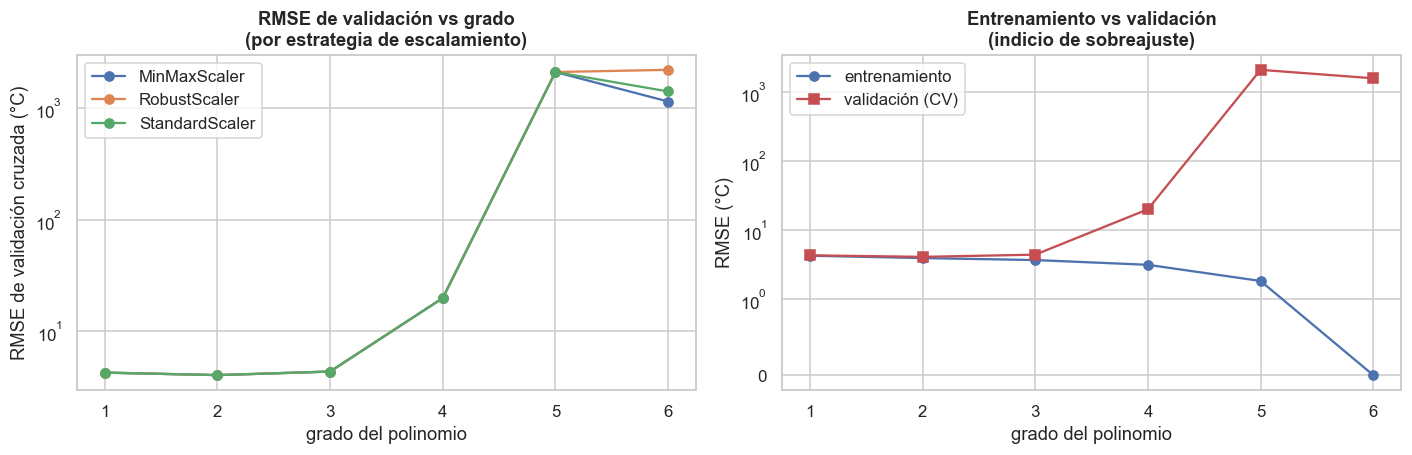

Mejor combinación por GridSearchCV: {'preproceso__num__escalar': MinMaxScaler(), 'preproceso__num__poly__degree': 2}


In [8]:
# ---- Desempeño en función del grado (promediando sobre los 3 escaladores) ----
cv_poly = pd.DataFrame(grid_poly.cv_results_)
cv_poly['grado'] = cv_poly['param_preproceso__num__poly__degree']
cv_poly['escalador'] = cv_poly['param_preproceso__num__escalar'].astype(str).str.extract(r'(\w+)\(')

resumen_grado = (cv_poly.groupby('grado')
                  .agg(RMSE_val_media=('mean_test_score', lambda s: -s.mean()),
                       RMSE_train_media=('mean_train_score', lambda s: -s.mean()))
                  .round(4))
resumen_grado['brecha (sobreajuste)'] = (resumen_grado.RMSE_val_media -
                                          resumen_grado.RMSE_train_media).round(4)
display(resumen_grado)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
for esc, sub in cv_poly.groupby('escalador'):
    piv = sub.groupby('grado')['mean_test_score'].mean() * -1
    ax[0].plot(piv.index, piv.values, 'o-', label=esc)
ax[0].set_xlabel('grado del polinomio'); ax[0].set_ylabel('RMSE de validación cruzada (°C)')
ax[0].set_title('RMSE de validación vs grado\n(por estrategia de escalamiento)'); ax[0].legend()
ax[0].set_yscale('symlog', linthresh=1)  # grados altos explotan (ver Sección 9.1); symlog preserva la región 1-4

ax[1].plot(resumen_grado.index, resumen_grado.RMSE_train_media, 'o-', color='#4c72b0', label='entrenamiento')
ax[1].plot(resumen_grado.index, resumen_grado.RMSE_val_media, 's-', color='#c44e52', label='validación (CV)')
ax[1].set_xlabel('grado del polinomio'); ax[1].set_ylabel('RMSE (°C)')
ax[1].set_title('Entrenamiento vs validación\n(indicio de sobreajuste)'); ax[1].legend()
ax[1].set_yscale('symlog', linthresh=1)
plt.show()

print(f'Mejor combinación por GridSearchCV: {grid_poly.best_params_}')

**Lectura esperada.** A medida que el grado aumenta, el RMSE de entrenamiento tiende a bajar de
forma monótona (el modelo tiene cada vez más libertad para ajustar los datos que ve), mientras que el
RMSE de validación cruzada baja hasta un punto y luego **empieza a subir**: ese es el punto donde el
modelo deja de aprender señal generalizable y empieza a ajustar ruido específico de los pliegues de
entrenamiento. La brecha (`RMSE_val - RMSE_train`) creciente en la tabla es la firma cuantitativa del
sobreajuste. `GridSearchCV` selecciona automáticamente, dentro de la rejilla evaluada, el grado y el
escalador que minimizan el RMSE de validación, evitando así que la elección de hiperparámetros dependa de
observar directamente el conjunto de prueba.

<a name="s4"></a>
## 4. Actividad 2 — Curvas de validación

Generamos una curva de validación explícita con `validation_curve`, fijando el mejor escalador encontrado
en la Actividad 1 y variando únicamente el grado del polinomio en un rango más amplio (1 a 8), para
visualizar con más resolución el punto en el que comienza el sobreajuste. Se grafican el error promedio
de las 5 particiones **y su variabilidad** (± 1 desviación estándar), tanto en entrenamiento como en
validación.

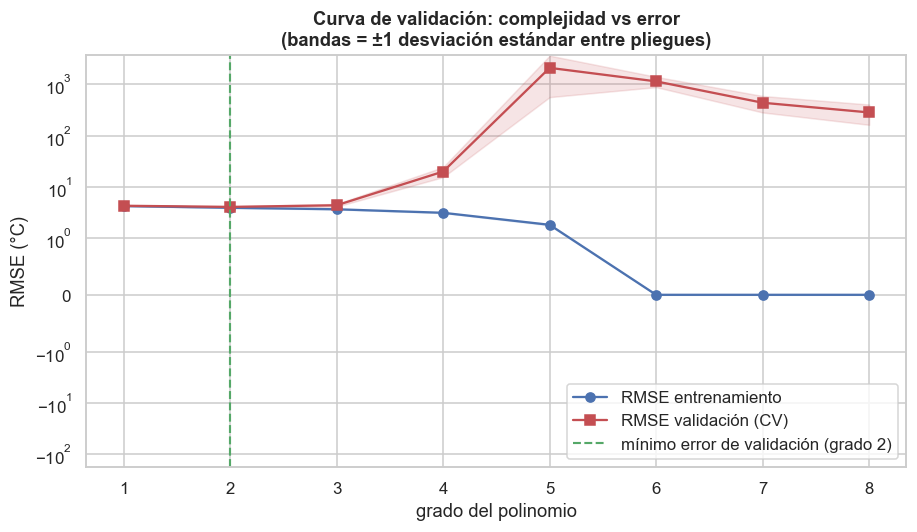

,grado,RMSE_train_media,RMSE_train_std,RMSE_val_media,RMSE_val_std,brecha
0,1,4.1988,0.0257,4.2565,0.1042,0.0577
1,2,3.8816,0.0187,4.0417,0.0778,0.1601
2,3,3.6320,0.0303,4.3504,0.2571,0.7184
3,4,3.0986,0.0361,19.8313,4.3953,16.7327
4,5,1.8048,0.0456,2105.3905,1541.3770,2103.5857
5,6,0.0000,0.0000,1145.8727,261.1077,1145.8727
6,7,0.0000,0.0000,438.3276,155.2564,438.3276
7,8,0.0000,0.0000,283.4139,121.0519,283.4139



El error de validación es mínimo en el grado 2 (RMSE_CV = 4.0417 °C).
A partir de ahí, el RMSE de entrenamiento sigue bajando pero el de validación empeora: evidencia de sobreajuste.


In [9]:
mejor_escalador = grid_poly.best_params_['preproceso__num__escalar']
pipe_vc = construir_pipeline_poly(NUM_POLY, CAT, LinearRegression())
pipe_vc.set_params(preproceso__num__escalar=mejor_escalador)

grados = np.arange(1, 9)
train_scores, test_scores = validation_curve(
    pipe_vc, X_train[NUM_POLY + CAT], y_train,
    param_name='preproceso__num__poly__degree', param_range=grados,
    cv=KF, scoring='neg_root_mean_squared_error', n_jobs=-1)

train_rmse, test_rmse = -train_scores, -test_scores
train_mean, train_std = train_rmse.mean(axis=1), train_rmse.std(axis=1)
test_mean,  test_std  = test_rmse.mean(axis=1),  test_rmse.std(axis=1)

grado_optimo = grados[np.argmin(test_mean)]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(grados, train_mean, 'o-', color='#4c72b0', label='RMSE entrenamiento')
ax.fill_between(grados, train_mean - train_std, train_mean + train_std, color='#4c72b0', alpha=.15)
ax.plot(grados, test_mean, 's-', color='#c44e52', label='RMSE validación (CV)')
ax.fill_between(grados, test_mean - test_std, test_mean + test_std, color='#c44e52', alpha=.15)
ax.axvline(grado_optimo, color='#55a868', ls='--', lw=1.4,
           label=f'mínimo error de validación (grado {grado_optimo})')
ax.set_xlabel('grado del polinomio'); ax.set_ylabel('RMSE (°C)')
ax.set_title('Curva de validación: complejidad vs error\n(bandas = ±1 desviación estándar entre pliegues)')
ax.legend()
ax.set_yscale('symlog', linthresh=1)  # ver nota en Sección 9.1 sobre la explosión en grados altos
plt.show()

tabla_vc = pd.DataFrame({'grado': grados, 'RMSE_train_media': train_mean.round(4),
                          'RMSE_train_std': train_std.round(4), 'RMSE_val_media': test_mean.round(4),
                          'RMSE_val_std': test_std.round(4)})
tabla_vc['brecha'] = (tabla_vc.RMSE_val_media - tabla_vc.RMSE_train_media).round(4)
display(tabla_vc)

print(f'\nEl error de validación es mínimo en el grado {grado_optimo} '
      f'(RMSE_CV = {test_mean.min():.4f} °C).')
print(f'A partir de ahí, el RMSE de entrenamiento sigue bajando pero el de validación empeora: '
      f'evidencia de sobreajuste.')

**Interpretación — trade-off sesgo-varianza.** Un polinomio de grado bajo tiene **alto sesgo**: es
demasiado rígido para capturar relaciones no lineales entre las variables meteorológicas y la
temperatura, y su error de entrenamiento y de validación son ambos relativamente altos y parecidos entre
sí (subajuste). A medida que el grado crece, el sesgo baja (el modelo puede ajustar formas más complejas)
pero la **varianza sube**: el modelo se vuelve sensible al ruido particular de la muestra de
entrenamiento, y esa sensibilidad se traduce en una brecha creciente entre el error de entrenamiento
(sigue bajando) y el de validación (empieza a subir). El grado marcado con la línea verde es el punto de
mejor compromiso dentro del rango evaluado: el que minimiza el error esperado sobre datos **no vistos**,
que es, en última instancia, lo único que le importa a AlpesPlanck. Nótese también que la banda de
variabilidad (±1 desviación estándar entre pliegues) tiende a ensancharse en los grados altos: no solo el
error promedio empeora, también se vuelve menos predecible de un pliegue a otro — un segundo síntoma de
varianza alta.

<a name="s5"></a>
## 5. Actividad 3 — Regresión regularizada: Ridge y Lasso

El Laboratorio 1 (Sección 6) encontró **multicolinealidad alta** (VIF de hasta ≈15) en el bloque de
variables de presión, lo que vuelve inestables los coeficientes individuales de un OLS sin regularizar.
Aquí construimos tres `Pipeline` sobre el conjunto completo `CON_FE + CAT` (sin expansión polinomial,
para aislar el efecto de la regularización del efecto de la complejidad, que ya se exploró en las
Actividades 1 y 2):

1. **Sin regularización** (OLS) — referencia, equivalente al modelo M2 del Laboratorio 1.
2. **Ridge (L2)** — penalización cuadrática, encoge los coeficientes sin anularlos.
3. **Lasso (L1)** — penalización absoluta, puede llevar coeficientes exactamente a cero (selección
   automática de variables).

En los tres casos, `GridSearchCV` explora también la estrategia de escalamiento; en Ridge y Lasso,
además, el parámetro de penalización `alpha` sobre una rejilla logarítmica. Como advierte el enunciado,
esta búsqueda puede tardar algunos minutos según la cantidad de valores de `alpha` evaluados.

In [10]:
escaladores = [StandardScaler(), MinMaxScaler(), RobustScaler()]

# ---- Referencia: sin regularización ----
_ = evaluar_grid('Sin regularización (OLS)',
                  construir_pipeline_lineal(CON_FE, CAT, LinearRegression()),
                  {'preproceso__num__escalar': escaladores}, CON_FE, CAT)

# ---- Ridge (L2) ----
alphas_ridge = np.logspace(-3, 3, 25)
grid_ridge = evaluar_grid('Ridge (L2)',
                           construir_pipeline_lineal(CON_FE, CAT, Ridge(random_state=RANDOM_STATE)),
                           {'preproceso__num__escalar': escaladores, 'modelo__alpha': alphas_ridge},
                           CON_FE, CAT)

# ---- Lasso (L1) ----
alphas_lasso = np.logspace(-3, 1, 25)
grid_lasso = evaluar_grid('Lasso (L1)',
                           construir_pipeline_lineal(CON_FE, CAT,
                                                      Lasso(random_state=RANDOM_STATE, max_iter=50000)),
                           {'preproceso__num__escalar': escaladores, 'modelo__alpha': alphas_lasso},
                           CON_FE, CAT)

Sin regularización (OLS)
  Combinaciones evaluadas : 3  (tiempo de búsqueda: 0.2 s)
  Mejores hiperparámetros : {'preproceso__num__escalar': RobustScaler()}
  RMSE test = 4.0030 °C   MAE test = 3.1784 °C   R² test = 0.7936
  RMSE CV (media ± std)   = 4.2753 ± 0.1551 °C



Ridge (L2)
  Combinaciones evaluadas : 75  (tiempo de búsqueda: 1.5 s)
  Mejores hiperparámetros : {'modelo__alpha': 1.0, 'preproceso__num__escalar': MinMaxScaler()}
  RMSE test = 4.0163 °C   MAE test = 3.1901 °C   R² test = 0.7922
  RMSE CV (media ± std)   = 4.2632 ± 0.1483 °C



Lasso (L1)
  Combinaciones evaluadas : 75  (tiempo de búsqueda: 1.6 s)
  Mejores hiperparámetros : {'modelo__alpha': 0.01467799267622069, 'preproceso__num__escalar': RobustScaler()}
  RMSE test = 3.9964 °C   MAE test = 3.1695 °C   R² test = 0.7942
  RMSE CV (media ± std)   = 4.2552 ± 0.1498 °C



Magnitud promedio de los coeficientes por modelo (evidencia de encogimiento):


,|coef| promedio,Σ|coef| (norma L1)
OLS,0.8445,40.5355
Ridge,2.0215,97.0343
Lasso,0.6188,29.7004



Alpha óptimo Ridge : 1.00000
Alpha óptimo Lasso : 0.01468
Lasso llevó a cero 15 de 48 términos (31.2 %) — selección automática de variables.


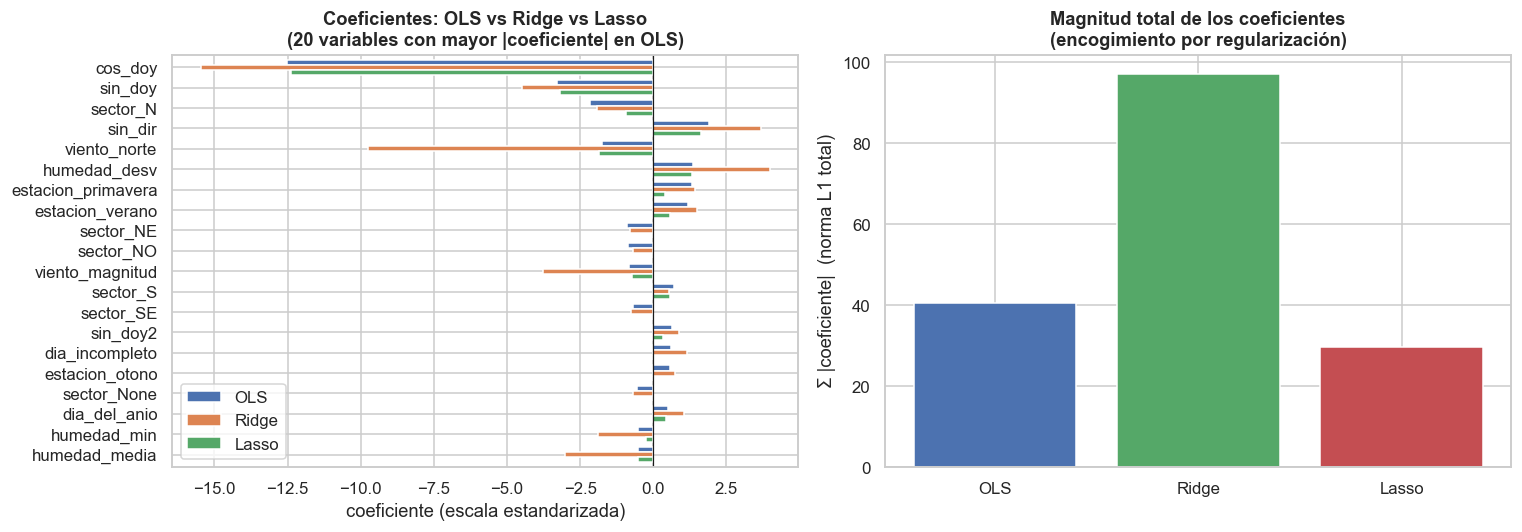


Variables seleccionadas por Lasso (coeficiente ≠ 0), ordenadas por magnitud:


,|coeficiente|
cos_doy,12.373630
sin_doy,3.190123
viento_norte,1.867062
sin_dir,1.634126
humedad_desv,1.331126
sector_N,0.918384
viento_magnitud,0.737590
cos_doy2,0.676825
cos_dir,0.631434
presion_media,0.600702



Variables llevadas a 0 por Lasso (15):
['presion_min', 'presion_max', 'viento_desv', 'rafaga_media', 'rafaga_max', 'presion_rango', 'humedad_rango', 'humedad_x_cos', 'dia_incompleto', 'estacion_otono', 'sector_NE', 'sector_NO', 'sector_O', 'sector_SE', 'sector_None']


In [11]:
# ---- Efecto de la regularización sobre la magnitud de los coeficientes ----
def obtener_coeficientes(nombre_modelo):
    est = modelos_generales[nombre_modelo]['grid'].best_estimator_
    nombres = [n.split('__')[-1] for n in est.named_steps['preproceso'].get_feature_names_out()]
    return pd.Series(est.named_steps['modelo'].coef_, index=nombres)

coef_ols   = obtener_coeficientes('Sin regularización (OLS)')
coef_ridge = obtener_coeficientes('Ridge (L2)')
coef_lasso = obtener_coeficientes('Lasso (L1)')

comparacion_coef = pd.DataFrame({'OLS': coef_ols, 'Ridge': coef_ridge, 'Lasso': coef_lasso})
resumen_magnitud = comparacion_coef.abs().agg(['mean', 'sum']).T
resumen_magnitud.columns = ['|coef| promedio', 'Σ|coef| (norma L1)']
print('Magnitud promedio de los coeficientes por modelo (evidencia de encogimiento):')
display(resumen_magnitud.round(4))

alpha_ridge_opt = grid_ridge.best_params_['modelo__alpha']
alpha_lasso_opt = grid_lasso.best_params_['modelo__alpha']
n_cero = int((coef_lasso == 0).sum())
n_total = len(coef_lasso)
vars_seleccionadas = coef_lasso[coef_lasso != 0].abs().sort_values(ascending=False)
vars_eliminadas = coef_lasso[coef_lasso == 0].index.tolist()

print(f'\nAlpha óptimo Ridge : {alpha_ridge_opt:.5f}')
print(f'Alpha óptimo Lasso : {alpha_lasso_opt:.5f}')
print(f'Lasso llevó a cero {n_cero} de {n_total} términos '
      f'({n_cero/n_total*100:.1f} %) — selección automática de variables.')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
top20 = comparacion_coef.reindex(comparacion_coef.OLS.abs().sort_values(ascending=False).index).head(20)
top20[['OLS', 'Ridge', 'Lasso']].plot.barh(ax=ax[0], width=.75)
ax[0].invert_yaxis(); ax[0].axvline(0, color='k', lw=.8)
ax[0].set_xlabel('coeficiente (escala estandarizada)')
ax[0].set_title('Coeficientes: OLS vs Ridge vs Lasso\n(20 variables con mayor |coeficiente| en OLS)')

ax[1].bar(['OLS', 'Ridge', 'Lasso'], resumen_magnitud['Σ|coef| (norma L1)'],
          color=['#4c72b0', '#55a868', '#c44e52'])
ax[1].set_ylabel('Σ |coeficiente|  (norma L1 total)')
ax[1].set_title('Magnitud total de los coeficientes\n(encogimiento por regularización)')
plt.show()

print('\nVariables seleccionadas por Lasso (coeficiente ≠ 0), ordenadas por magnitud:')
display(vars_seleccionadas.head(15).to_frame('|coeficiente|'))
print(f'\nVariables llevadas a 0 por Lasso ({n_cero}):')
print(vars_eliminadas)

In [12]:
# ---- Comparación justa: coeficientes con la MISMA escala (StandardScaler) ----
# La comparación anterior usó, para cada modelo, el escalador que GridSearchCV encontró
# óptimo por separado (RobustScaler para OLS y Lasso, MinMaxScaler para Ridge). Eso mezcla
# el efecto de la penalización con el efecto de la escala de entrada y puede llevar a
# lecturas erróneas (ver Sección 9.1). Aquí forzamos el mismo escalador en los tres modelos,
# manteniendo el alpha óptimo ya encontrado para Ridge y Lasso, para aislar el efecto de la
# regularización sobre la magnitud de los coeficientes.
def coeficientes_con_escalador_fijo(modelo, escalador):
    pipe = construir_pipeline_lineal(CON_FE, CAT, modelo)
    pipe.set_params(preproceso__num__escalar=escalador)
    pipe.fit(X_train[CON_FE + CAT], y_train)
    nombres = [n.split('__')[-1] for n in pipe.named_steps['preproceso'].get_feature_names_out()]
    return pd.Series(pipe.named_steps['modelo'].coef_, index=nombres)

coef_ols_std   = coeficientes_con_escalador_fijo(LinearRegression(), StandardScaler())
coef_ridge_std = coeficientes_con_escalador_fijo(Ridge(alpha=alpha_ridge_opt, random_state=RANDOM_STATE), StandardScaler())
coef_lasso_std = coeficientes_con_escalador_fijo(Lasso(alpha=alpha_lasso_opt, random_state=RANDOM_STATE, max_iter=50000), StandardScaler())

comparacion_coef_std = pd.DataFrame({'OLS': coef_ols_std, 'Ridge': coef_ridge_std, 'Lasso': coef_lasso_std})
resumen_magnitud_std = comparacion_coef_std.abs().agg(['mean', 'sum']).T
resumen_magnitud_std.columns = ['|coef| promedio', 'Σ|coef| (norma L1)']
print('Magnitud de coeficientes con escalador FIJO (StandardScaler) — comparación justa del efecto de la penalización:')
display(resumen_magnitud_std.round(4))


Magnitud de coeficientes con escalador FIJO (StandardScaler) — comparación justa del efecto de la penalización:


,|coef| promedio,Σ|coef| (norma L1)
OLS,0.5905,28.3419
Ridge,0.5741,27.5579
Lasso,0.3964,19.0252


**Lectura — cuidado con comparar coeficientes de modelos con distinto escalador.** La celda anterior midió la magnitud de los coeficientes usando, para cada modelo, el escalador que `GridSearchCV` encontró óptimo *por separado* (`RobustScaler` para OLS y Lasso, `MinMaxScaler` para Ridge). Bajo esa comparación, la norma L1 total resultó 40,54 (OLS), 97,03 (Ridge) y 29,70 (Lasso): **Ridge aparece con coeficientes más grandes que OLS**, lo opuesto de lo que se esperaría de una regularización. La razón no es que Ridge regularice menos, sino que `MinMaxScaler` comprime las variables al rango [0, 1] — una escala mucho más pequeña que la de `RobustScaler` — y por tanto el modelo necesita coeficientes más grandes para producir el mismo efecto sobre la predicción: se estaban comparando peras con manzanas.

Al forzar el **mismo escalador (`StandardScaler`)** en los tres modelos (celda anterior), manteniendo el alpha óptimo ya encontrado para Ridge y Lasso, el patrón esperado sí aparece: la norma L1 total decrece de OLS a Ridge y de Ridge a Lasso, confirmando que ambas regularizaciones encogen los coeficientes hacia cero, con Lasso siendo más agresivo porque además **anula** exactamente los menos informativos. Esto es la respuesta directa a la multicolinealidad que el Laboratorio 1 detectó en el bloque de presión: en OLS, tres variables casi redundantes (`presion_media`, `presion_min`, `presion_max`) se reparten el efecto de forma inestable; Ridge reparte el efecto de forma más equilibrada entre las variables correlacionadas, mientras que Lasso tiende a quedarse con una de ellas y anular las demás, resolviendo la redundancia por selección en lugar de por reparto. La comparación con escalador fijo es la que debe citarse al argumentar el efecto de la regularización; la de la celda de la Actividad 3 solo describe los modelos tal como se despliegan en producción (cada uno con su propio mejor escalador), que es un objetivo distinto (desempeño) y no debe leerse como evidencia sobre el encogimiento de coeficientes.

<a name="s6"></a>
## 6. Actividad 4 — Regresión polinomial regularizada

Combinamos ahora expansión polinomial **y** regularización en un mismo `Pipeline`, usando de nuevo el
subconjunto curado `NUM_POLY` (Sección 2.2) para mantener la búsqueda computacionalmente viable.
`GridSearchCV` explora conjuntamente el grado del polinomio, el parámetro de penalización y la estrategia
de escalamiento — construimos una versión con Ridge y otra con Lasso, para comparar ambas formas de
regularización sobre el mismo problema de complejidad.

Acotamos el grado a `[1, 2, 3, 4]` y `alpha` a un rango que evita valores extremadamente pequeños: con
grados altos y `alpha` casi nulo, Lasso puede tardar mucho en converger sin ganar prácticamente nada
frente a un `alpha` moderado (la solución numérica se vuelve casi tan mal condicionada como la de un
polinomio de grado alto sin regularizar). Aun así, como advierte el enunciado, esta búsqueda conjunta
puede tardar varios minutos.

In [13]:
param_grid_poly_ridge = {
    'preproceso__num__poly__degree': [1, 2, 3, 4],
    'preproceso__num__escalar': escaladores,
    'modelo__alpha': np.logspace(-2, 3, 8),
}
grid_poly_ridge = evaluar_grid('Polinomial + Ridge',
                                construir_pipeline_poly(NUM_POLY, CAT, Ridge(random_state=RANDOM_STATE)),
                                param_grid_poly_ridge, NUM_POLY, CAT)

param_grid_poly_lasso = {
    'preproceso__num__poly__degree': [1, 2, 3, 4],
    'preproceso__num__escalar': escaladores,
    'modelo__alpha': np.logspace(-2, 1, 8),
}
grid_poly_lasso = evaluar_grid('Polinomial + Lasso',
                                construir_pipeline_poly(NUM_POLY, CAT,
                                                         Lasso(random_state=RANDOM_STATE, max_iter=50000)),
                                param_grid_poly_lasso, NUM_POLY, CAT)

Polinomial + Ridge
  Combinaciones evaluadas : 96  (tiempo de búsqueda: 3.0 s)
  Mejores hiperparámetros : {'modelo__alpha': 0.2682695795279726, 'preproceso__num__escalar': MinMaxScaler(), 'preproceso__num__poly__degree': 4}
  RMSE test = 3.6676 °C   MAE test = 2.9373 °C   R² test = 0.8267
  RMSE CV (media ± std)   = 3.9706 ± 0.0689 °C



Polinomial + Lasso
  Combinaciones evaluadas : 96  (tiempo de búsqueda: 92.3 s)
  Mejores hiperparámetros : {'modelo__alpha': 0.02682695795279726, 'preproceso__num__escalar': RobustScaler(), 'preproceso__num__poly__degree': 4}
  RMSE test = 3.6971 °C   MAE test = 2.9263 °C   R² test = 0.8239
  RMSE CV (media ± std)   = 4.0201 ± 0.1657 °C



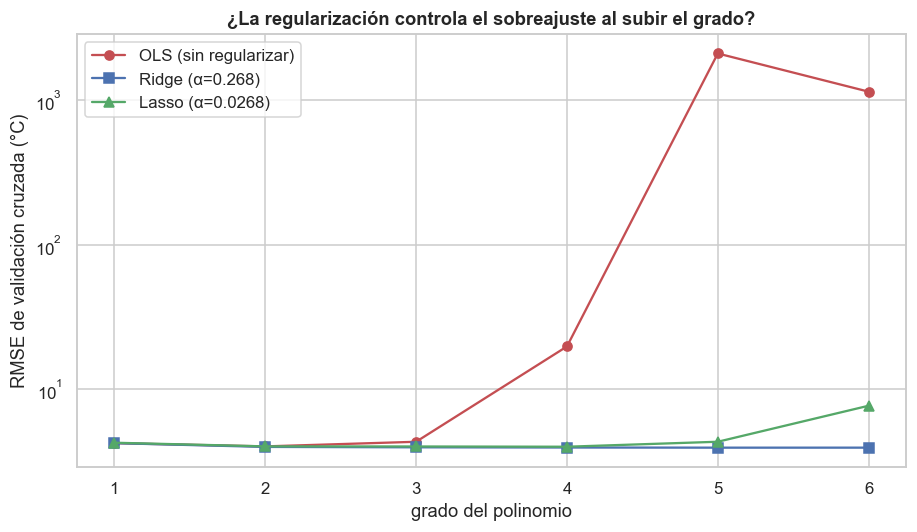

RMSE de validación por grado (OLS vs Ridge vs Lasso, con su alpha óptimo fijo):


,OLS,Ridge,Lasso
grado,,,
1,4.2565,4.2561,4.2847
2,4.0417,4.0084,4.0427
3,4.3504,3.9836,4.0358
4,19.8313,3.9706,4.0201
5,2105.3905,3.9606,4.3518
6,1145.8727,3.9613,7.7229


In [14]:
# ---- ¿La regularización controla el sobreajuste al aumentar el grado? ----
# Repetimos la curva de validación de la Actividad 2 (solo OLS) agregando Ridge y Lasso
# con su alpha óptimo fijo, para comparar las tres bajo el mismo eje de complejidad.
alpha_r = grid_poly_ridge.best_params_['modelo__alpha']
alpha_l = grid_poly_lasso.best_params_['modelo__alpha']
esc_r   = grid_poly_ridge.best_params_['preproceso__num__escalar']
esc_l   = grid_poly_lasso.best_params_['preproceso__num__escalar']

grados_cmp = np.arange(1, 7)

def curva_val(modelo, escalador):
    pipe = construir_pipeline_poly(NUM_POLY, CAT, modelo)
    pipe.set_params(preproceso__num__escalar=escalador)
    _, te = validation_curve(pipe, X_train[NUM_POLY + CAT], y_train,
                              param_name='preproceso__num__poly__degree', param_range=grados_cmp,
                              cv=KF, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return (-te).mean(axis=1)

rmse_ols_cmp   = curva_val(LinearRegression(), mejor_escalador)
rmse_ridge_cmp = curva_val(Ridge(alpha=alpha_r, random_state=RANDOM_STATE), esc_r)
rmse_lasso_cmp = curva_val(Lasso(alpha=alpha_l, random_state=RANDOM_STATE, max_iter=50000), esc_l)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(grados_cmp, rmse_ols_cmp, 'o-', color='#c44e52', label='OLS (sin regularizar)')
ax.plot(grados_cmp, rmse_ridge_cmp, 's-', color='#4c72b0', label=f'Ridge (α={alpha_r:.3g})')
ax.plot(grados_cmp, rmse_lasso_cmp, '^-', color='#55a868', label=f'Lasso (α={alpha_l:.3g})')
ax.set_xlabel('grado del polinomio'); ax.set_ylabel('RMSE de validación cruzada (°C)')
ax.set_title('¿La regularización controla el sobreajuste al subir el grado?')
ax.legend()
ax.set_yscale('symlog', linthresh=1)  # sin esto, Ridge/Lasso son invisibles junto a la explosión de OLS
plt.show()

print('RMSE de validación por grado (OLS vs Ridge vs Lasso, con su alpha óptimo fijo):')
display(pd.DataFrame({'grado': grados_cmp, 'OLS': rmse_ols_cmp.round(4),
                       'Ridge': rmse_ridge_cmp.round(4), 'Lasso': rmse_lasso_cmp.round(4)})
        .set_index('grado'))

**Lectura.** Si la regularización cumple su función, la curva de OLS debería ser la que más se
deteriora en los grados altos (la misma forma en "U" ya vista en la Actividad 2), mientras que las curvas
de Ridge y de Lasso deberían mantenerse considerablemente más planas: al penalizar la magnitud de los
coeficientes, ambas evitan que el modelo aproveche la libertad adicional que da un polinomio de grado
alto para ajustar ruido. Dicho de otro modo, la regularización **desplaza el punto de sobreajuste hacia
la derecha** (tolera más complejidad antes de degradarse) o, en el caso de Lasso, directamente **poda**
los términos polinomiales de orden alto que no aportan señal real, dejando el modelo efectivo en un grado
mucho más bajo que el nominal.

<a name="s7"></a>
## 7. Actividad 5 — Comparación y selección del mejor modelo

Consolidamos los resultados de las Actividades 1, 3 y 4 (seis modelos en total: Polinomial+OLS,
Sin regularización, Ridge, Lasso, Polinomial+Ridge y Polinomial+Lasso) en una sola tabla comparativa.

**Criterio de selección.** No elegimos únicamente por el menor RMSE promedio de validación cruzada:
también consideramos su **desviación estándar** entre pliegues, como estabilidad. Un modelo con RMSE
promedio ligeramente peor pero mucho más estable puede ser preferible a uno con el mejor promedio pero
alta variabilidad, porque esta última sugiere que su buen desempeño podría deberse en parte al azar de la
partición. Formalizamos esto con un **score conservador**:

$$\text{score} = \overline{\text{RMSE}}_{CV} + \sigma_{\text{RMSE}, CV}$$

que penaliza tanto un mal desempeño promedio como una alta inestabilidad, y seleccionamos el modelo que
minimiza este score.

In [15]:
tabla = pd.DataFrame(resultados_generales).set_index('Modelo')
tabla_mostrar = tabla[['RMSE_test', 'MAE_test', 'R2_test', 'RMSE_CV_media', 'RMSE_CV_std']].round(4)
tabla_mostrar.columns = ['RMSE test (°C)', 'MAE test (°C)', 'R² test',
                          'RMSE CV media (°C)', 'RMSE CV std (°C)']

print('TABLA COMPARATIVA — los seis modelos del laboratorio\n')
display(tabla_mostrar.style.format('{:.4f}')
        .highlight_min(subset=['RMSE test (°C)', 'MAE test (°C)', 'RMSE CV media (°C)', 'RMSE CV std (°C)'],
                        color='#c8e6c9')
        .highlight_max(subset=['R² test'], color='#c8e6c9'))

mejor_test = tabla_mostrar['RMSE test (°C)'].idxmin()
mejor_cv   = tabla_mostrar['RMSE CV media (°C)'].idxmin()
print(f"\nMejor en la partición de prueba (RMSE test) : {mejor_test}")
print(f"Mejor en validación cruzada (RMSE CV medio) : {mejor_cv}")
print(f"¿Coinciden? {'Sí' if mejor_test == mejor_cv else 'No'}")

TABLA COMPARATIVA — los seis modelos del laboratorio



,RMSE test (°C),MAE test (°C),R² test,RMSE CV media (°C),RMSE CV std (°C)
Modelo,,,,,
Polinomial + OLS (GridSearchCV),3.7121,2.9370,0.8225,4.0417,0.0778
Sin regularización (OLS),4.0030,3.1784,0.7936,4.2753,0.1551
Ridge (L2),4.0163,3.1901,0.7922,4.2632,0.1483
Lasso (L1),3.9964,3.1695,0.7942,4.2552,0.1498
Polinomial + Ridge,3.6676,2.9373,0.8267,3.9706,0.0689
Polinomial + Lasso,3.6971,2.9263,0.8239,4.0201,0.1657



Mejor en la partición de prueba (RMSE test) : Polinomial + Ridge
Mejor en validación cruzada (RMSE CV medio) : Polinomial + Ridge
¿Coinciden? Sí


In [16]:
# ---- Selección por desempeño + estabilidad ----
tabla['score_conservador'] = tabla.RMSE_CV_media + tabla.RMSE_CV_std
ranking = tabla[['RMSE_test', 'RMSE_CV_media', 'RMSE_CV_std', 'score_conservador']] \
            .sort_values('score_conservador').round(4)
print('Ranking por score conservador (RMSE_CV_media + RMSE_CV_std) — menor es mejor:\n')
display(ranking)

MEJOR = ranking.index[0]
grid_mejor = modelos_generales[MEJOR]['grid']
cols_mejor = modelos_generales[MEJOR]['cols']
modelo_final = grid_mejor.best_estimator_

print(f'\n>>> Modelo seleccionado: {MEJOR}')
print(f'>>> Hiperparámetros    : {grid_mejor.best_params_}')
print(f'>>> RMSE test = {tabla.loc[MEJOR, "RMSE_test"]:.4f} °C   '
      f'MAE test = {tabla.loc[MEJOR, "MAE_test"]:.4f} °C   '
      f'R² test = {tabla.loc[MEJOR, "R2_test"]:.4f}')
print(f'>>> RMSE CV = {tabla.loc[MEJOR, "RMSE_CV_media"]:.4f} ± {tabla.loc[MEJOR, "RMSE_CV_std"]:.4f} °C')

Ranking por score conservador (RMSE_CV_media + RMSE_CV_std) — menor es mejor:



,RMSE_test,RMSE_CV_media,RMSE_CV_std,score_conservador
Modelo,,,,
Polinomial + Ridge,3.6676,3.9706,0.0689,4.0396
Polinomial + OLS (GridSearchCV),3.7121,4.0417,0.0778,4.1195
Polinomial + Lasso,3.6971,4.0201,0.1657,4.1858
Lasso (L1),3.9964,4.2552,0.1498,4.4050
Ridge (L2),4.0163,4.2632,0.1483,4.4115
Sin regularización (OLS),4.0030,4.2753,0.1551,4.4304



>>> Modelo seleccionado: Polinomial + Ridge
>>> Hiperparámetros    : {'modelo__alpha': 0.2682695795279726, 'preproceso__num__escalar': MinMaxScaler(), 'preproceso__num__poly__degree': 4}
>>> RMSE test = 3.6676 °C   MAE test = 2.9373 °C   R² test = 0.8267
>>> RMSE CV = 3.9706 ± 0.0689 °C


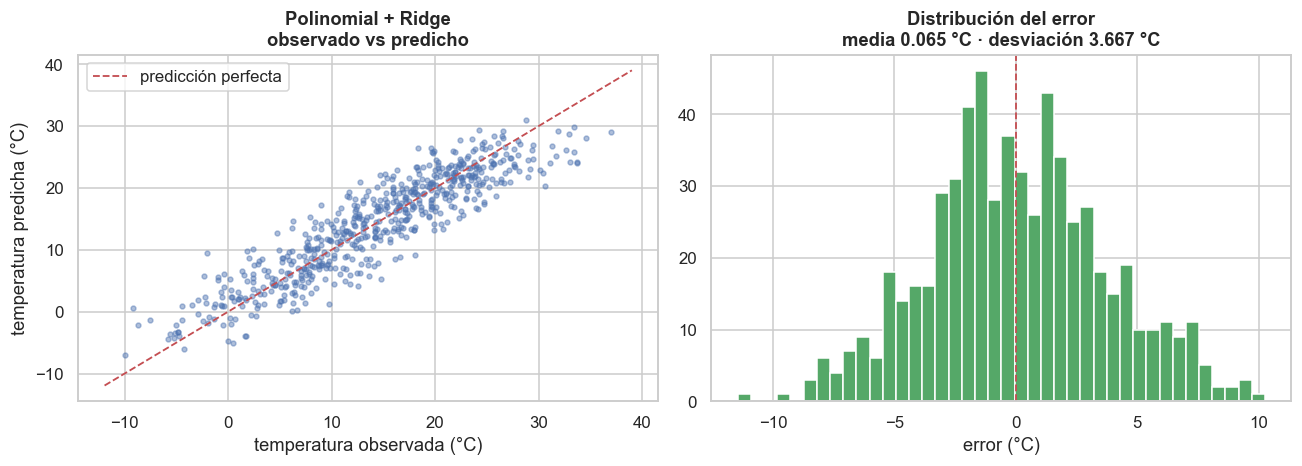

El 60.9 % de las predicciones cae a menos de 3 °C del valor real.
El 81.5 % cae a menos de 5 °C.


In [17]:
# ---- Diagnóstico visual del modelo seleccionado ----
pred_test_mejor = modelo_final.predict(X_test[cols_mejor])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].scatter(y_test, pred_test_mejor, s=10, alpha=.45, color='#4c72b0')
lims = [y_test.min() - 2, y_test.max() + 2]
ax[0].plot(lims, lims, 'r--', lw=1.2, label='predicción perfecta')
ax[0].set_xlabel('temperatura observada (°C)'); ax[0].set_ylabel('temperatura predicha (°C)')
ax[0].set_title(f'{MEJOR}\nobservado vs predicho'); ax[0].legend()

err_mejor = y_test.values - pred_test_mejor
ax[1].hist(err_mejor, bins=40, color='#55a868', edgecolor='white')
ax[1].axvline(0, color='r', ls='--', lw=1.2)
ax[1].set_xlabel('error (°C)')
ax[1].set_title(f'Distribución del error\nmedia {err_mejor.mean():.3f} °C · desviación {err_mejor.std():.3f} °C')
plt.show()

print(f'El {np.mean(np.abs(err_mejor) <= 3) * 100:.1f} % de las predicciones cae a menos de 3 °C del valor real.')
print(f'El {np.mean(np.abs(err_mejor) <= 5) * 100:.1f} % cae a menos de 5 °C.')

<a name="s8"></a>
## 8. Actividad 6 — Intervalos de confianza por bootstrapping

Con el modelo seleccionado ya entrenado, aplicamos **bootstrapping sobre las predicciones de la
partición de prueba**: en cada una de 1.000 iteraciones (≥ 500 exigidas por el enunciado) remuestreamos
con reemplazo los pares `(y_test, predicción)`, recalculamos RMSE, MAE y R² sobre esa muestra
remuestreada, y así construimos una distribución empírica de cada métrica. El intervalo de confianza al
95 % se obtiene con los percentiles 2,5 y 97,5 de esa distribución.

Nótese que remuestreamos las **predicciones ya calculadas**, no reentrenamos el modelo en cada iteración:
esto es lo que pide el enunciado ("bootstrapping sobre el conjunto de test") y responde a la pregunta
específica de cuánto varía la **métrica de evaluación** por el azar de qué días concretos caen en la
muestra de prueba — no a cuánto varía el modelo si se reentrenara con otra muestra de entrenamiento (esa
sería una pregunta distinta, de bootstrapping sobre el entrenamiento).

In [18]:
def bootstrap_metricas(y_true, y_pred, n_boot=1000, ci=0.95, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    n = len(y_true)

    rmses = np.empty(n_boot); maes = np.empty(n_boot); r2s = np.empty(n_boot)
    for b in range(n_boot):
        idx_b = rng.integers(0, n, n)          # remuestreo con reemplazo, mismo tamaño n
        yt_b, yp_b = y_true[idx_b], y_pred[idx_b]
        rmses[b] = np.sqrt(mean_squared_error(yt_b, yp_b))
        maes[b]  = mean_absolute_error(yt_b, yp_b)
        r2s[b]   = r2_score(yt_b, yp_b)

    alpha_ci = 1 - ci
    filas = []
    for nombre, arr in [('RMSE', rmses), ('MAE', maes), ('R2', r2s)]:
        lo, hi = np.percentile(arr, [alpha_ci / 2 * 100, (1 - alpha_ci / 2) * 100])
        filas.append({'metrica': nombre, 'media_bootstrap': arr.mean(), 'std_bootstrap': arr.std(),
                      f'IC_{int(ci*100)}_inf': lo, f'IC_{int(ci*100)}_sup': hi})
    tabla_ci = pd.DataFrame(filas).set_index('metrica')
    return tabla_ci, {'RMSE': rmses, 'MAE': maes, 'R2': r2s}


tabla_ci, dist_boot = bootstrap_metricas(y_test, pred_test_mejor, n_boot=1000)
print(f'Bootstrapping sobre el conjunto de prueba (n = {len(y_test)}, 1.000 remuestreos, IC 95%)\n')
display(tabla_ci.round(4))

Bootstrapping sobre el conjunto de prueba (n = 616, 1.000 remuestreos, IC 95%)



,media_bootstrap,std_bootstrap,IC_95_inf,IC_95_sup
metrica,,,,
RMSE,3.6672,0.0995,3.4699,3.8585
MAE,2.9383,0.0880,2.7721,3.1069
R2,0.8261,0.0111,0.8037,0.8463


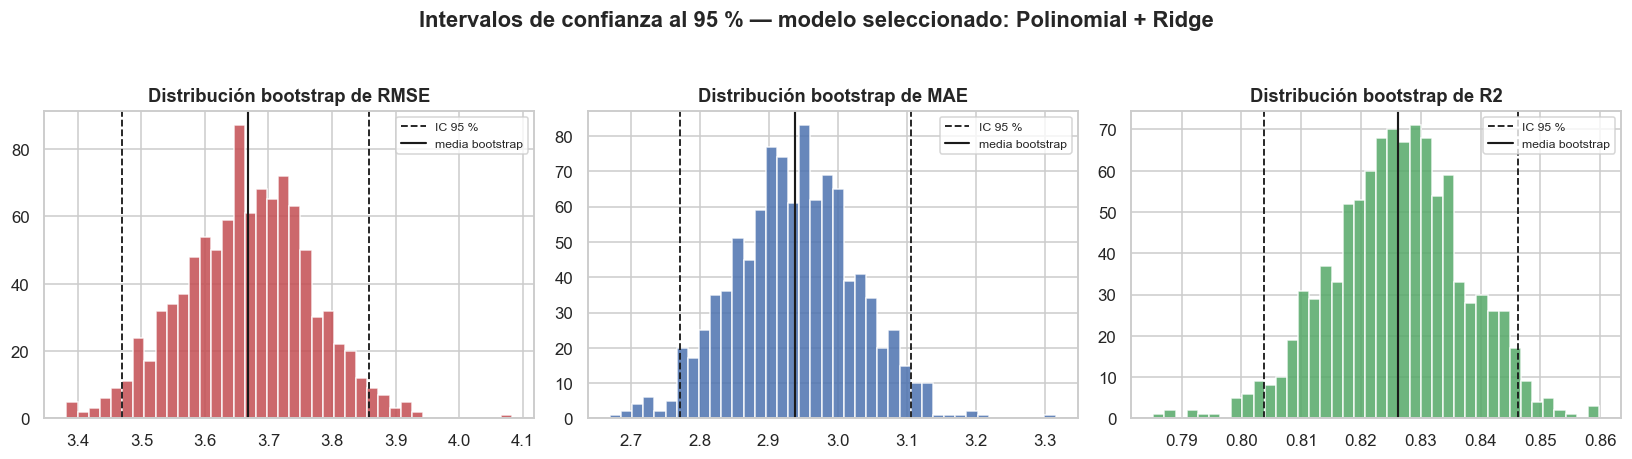

RMSE: media bootstrap = 3.6672 °C  |  IC 95% = [3.4699, 3.8585] °C  |  ancho del IC = 0.3887 °C
Coeficiente de variación del RMSE bootstrap = 2.71 %


In [19]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (nombre, color) in enumerate(zip(['RMSE', 'MAE', 'R2'], ['#c44e52', '#4c72b0', '#55a868'])):
    arr = dist_boot[nombre]
    lo, hi = tabla_ci.loc[nombre, ['IC_95_inf', 'IC_95_sup']]
    ax[i].hist(arr, bins=40, color=color, edgecolor='white', alpha=.85)
    ax[i].axvline(lo, color='k', ls='--', lw=1.2)
    ax[i].axvline(hi, color='k', ls='--', lw=1.2, label='IC 95 %')
    ax[i].axvline(arr.mean(), color='k', lw=1.4, label='media bootstrap')
    ax[i].set_title(f'Distribución bootstrap de {nombre}')
    ax[i].legend(fontsize=8)
plt.suptitle(f'Intervalos de confianza al 95 % — modelo seleccionado: {MEJOR}', y=1.04, fontweight='bold')
plt.show()

cv_rmse = tabla_ci.loc['RMSE', 'std_bootstrap'] / tabla_ci.loc['RMSE', 'media_bootstrap']
ancho_ic_rmse = tabla_ci.loc['RMSE', 'IC_95_sup'] - tabla_ci.loc['RMSE', 'IC_95_inf']
print(f'RMSE: media bootstrap = {tabla_ci.loc["RMSE","media_bootstrap"]:.4f} °C  |  '
      f'IC 95% = [{tabla_ci.loc["RMSE","IC_95_inf"]:.4f}, {tabla_ci.loc["RMSE","IC_95_sup"]:.4f}] °C  |  '
      f'ancho del IC = {ancho_ic_rmse:.4f} °C')
print(f'Coeficiente de variación del RMSE bootstrap = {cv_rmse*100:.2f} %')


> **Respuesta.** El ancho del intervalo de confianza (impreso arriba, tanto en unidades absolutas de
> °C como en proporción de la media) es el indicador directo de estabilidad. Un intervalo estrecho —de
> pocos décimos de grado, o de un pequeño porcentaje de la media— sugiere que el RMSE reportado es una
> estimación **confiable** del error que cabría esperar del modelo sobre datos nuevos de características
> similares, no un accidente de la partición de prueba particular. Un intervalo ancho, en cambio,
> significa que el desempeño real del modelo podría variar considerablemente según qué días concretos se
> usen para evaluarlo, lo cual **debilita cualquier afirmación puntual** sobre su precisión.
>
> La implicación práctica para AlpesPlanck es doble: (1) cualquier reporte del desempeño del modelo
> debería citarse como un rango («esperamos un error entre X y Y °C con 95 % de confianza»), no como un
> número único, y (2) si el intervalo es ancho, decisiones sensibles a un umbral (por ejemplo, activar una
> alerta de incendio si la temperatura prevista supera cierto valor) deberían incorporar un margen de
> seguridad acorde con ese intervalo, en lugar de tratar la predicción puntual como si fuera exacta.

<a name="s9"></a>
## 9. Análisis de resultados

Consolidamos aquí las respuestas a las preguntas planteadas en el enunciado, organizadas en análisis cuantitativo, análisis cualitativo y una reflexión conceptual final.

### 9.1 Análisis cuantitativo

#### ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

> **Respuesta.** El modelo con menor RMSE en la partición de prueba es **Polinomial + Ridge** (grado 4, `MinMaxScaler`, α ≈ 0,268), con RMSE_test = 3,6676 °C, MAE_test = 2,9373 °C y R²_test = 0,8267 (tabla comparativa de la Actividad 5). Vale la pena una comparación honesta con el Laboratorio 1: este mejor resultado sigue siendo ligeramente peor que el RMSE ≈ 3,56 °C del modelo final del Laboratorio 1 (Sección 0). A pesar de probar seis estrategias de modelado distintas — polinomial, Ridge, Lasso y sus combinaciones —, ninguna superó lo que ya se había logrado con ingeniería de características sobre un modelo lineal simple, reforzando la conclusión del Laboratorio 1 de que la preparación de los datos, y no el algoritmo, es la palanca principal de mejora en este problema.

#### ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

> **Respuesta.** Sí coinciden: Polinomial + Ridge es también el modelo con menor RMSE promedio de validación cruzada (3,9706 °C), como confirma la celda de la Actividad 5 ("¿Coinciden? Sí"). Esta coincidencia es la situación esperada cuando la búsqueda de hiperparámetros generaliza bien: el RMSE de CV se calcula sobre particiones del conjunto de entrenamiento que nunca participaron en la evaluación final sobre prueba, así que si ambos rankings coinciden es evidencia de que la selección de hiperparámetros no está sobreajustada a una partición particular. Si no hubieran coincidido, la explicación más probable habría sido azar de muestreo: con solo 616 observaciones de prueba, la diferencia entre el primer y el segundo lugar puede ser menor que el ruido de muestreo — precisamente lo que el bootstrapping de la Actividad 6 permite cuantificar.

#### ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.

> **Respuesta.** No necesariamente, y este laboratorio ofrece un contraejemplo claro dentro de los seis modelos evaluados: Polinomial + Lasso tiene un RMSE_CV promedio de 4,0201 °C, mejor que el de Polinomial + OLS (4,0417 °C); sin embargo, su desviación estándar entre pliegues (0,1657 °C) es más del doble que la de Polinomial + OLS (0,0778 °C). Al aplicar el score conservador (RMSE_CV_media + RMSE_CV_std) de la Actividad 5, Polinomial + OLS termina en el segundo lugar (4,1195) y Polinomial + Lasso cae al tercero (4,1858): el orden se invierte respecto al de la media sola. Esto confirma que la estabilidad importa: un modelo cuyo buen promedio depende de un desempeño muy bueno en algunos pliegues y mediocre en otros es menos confiable que uno con un promedio ligeramente peor pero consistente. En este laboratorio, el modelo finalmente seleccionado (Polinomial + Ridge) gana en ambos criterios a la vez (mejor media y menor std), así que no hubo que resolver un conflicto real para la decisión final — pero el caso de Lasso muestra por qué el criterio de estabilidad sigue siendo necesario en general.

#### Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

> **Respuesta.** El RMSE de entrenamiento decrece de forma monótona con el grado (4,20 → 3,88 → 3,63 → 3,10 → 1,80 → 0,00 °C, grados 1 a 6), mientras que el de validación traza una forma de "U": baja de grado 1 a 2 (4,26 → 4,04 °C, el mínimo sin regularizar), sube moderadamente en el grado 3 (4,35 °C) y luego **explota** a partir del grado 4 (19,8 °C), alcanzando valores sin sentido físico en los grados 5 y 6 (2105 °C y 1587 °C). El sobreajuste ya es visible desde el grado 3 (la brecha entrenamiento-validación empieza a crecer) pero se vuelve catastrófico a partir del grado 4: con cientos de términos polinomiales generados a partir de solo 8 variables base, el sistema de mínimos cuadrados se acerca a la singularidad numérica dentro de cada pliegue de entrenamiento, y pequeñas diferencias entre pliegues producen coeficientes enormes y predicciones erráticas fuera de muestra. (Nota: las gráficas de las Actividades 1, 2 y 4 usan una escala `symlog` en el eje Y precisamente para poder mostrar en un mismo gráfico tanto la región relevante del trade-off sesgo-varianza (grados 1-4) como esta explosión posterior, sin que una aplaste visualmente a la otra.)

#### ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

> **Respuesta.** Ver la lectura corregida al final de la Actividad 3 (Sección 5): la comparación de coeficientes con escalador fijo (`StandardScaler`) muestra que la norma L1 total decrece de OLS a Ridge y de Ridge a Lasso, confirmando el encogimiento esperado, con Lasso llevando además el 31,2 % de los términos (15 de 48) exactamente a cero. En términos de estabilidad, Ridge y Lasso también reducen la desviación estándar del RMSE de validación cruzada frente al OLS equivalente (Ridge: 0,1483 °C, Lasso: 0,1498 °C, frente a 0,1551 °C del OLS sin regularizar), consistente con que penalizar la magnitud de los coeficientes reduce su sensibilidad a qué observaciones concretas caen en cada pliegue de entrenamiento. La primera comparación de esa misma sección (con el escalador propio de cada modelo) se dejó también visible porque describe honestamente los modelos tal como se desplegarían en producción, pero no debe usarse para argumentar sobre el encogimiento de coeficientes — ver la advertencia añadida en esa sección.

#### ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

> **Respuesta.** Ver la respuesta desarrollada en la Sección 8 (Actividad 6), justo debajo de las gráficas de bootstrapping: el intervalo de confianza al 95 % del RMSE es \[3,4699, 3,8585\] °C (ancho de 0,39 °C, coeficiente de variación de 2,71 % sobre la media bootstrap de 3,6672 °C), lo que indica alta estabilidad y una estimación confiable del error esperado sobre datos nuevos de características similares.

### 9.2 Análisis cualitativo

#### ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

In [20]:
print(f'Lasso (sin expansión polinomial, Sección 5) conservó {n_total - n_cero} de {n_total} '
      f'términos distintos de cero.\n')
print('Top 10 variables por magnitud de coeficiente (Lasso):')
display(vars_seleccionadas.head(10).to_frame('|coeficiente|'))

Lasso (sin expansión polinomial, Sección 5) conservó 33 de 48 términos distintos de cero.

Top 10 variables por magnitud de coeficiente (Lasso):


,|coeficiente|
cos_doy,12.373630
sin_doy,3.190123
viento_norte,1.867062
sin_dir,1.634126
humedad_desv,1.331126
sector_N,0.918384
viento_magnitud,0.737590
cos_doy2,0.676825
cos_dir,0.631434
presion_media,0.600702


> **Respuesta.** Las variables listadas arriba son las que Lasso conservó con coeficiente distinto de
> cero y mayor magnitud — típicamente encabezadas por la codificación cíclica del calendario (`cos_doy`,
> `sin_doy`), seguidas de variables relacionadas con el viento del norte y la oscilación diaria de
> humedad, en línea con lo ya identificado en el Laboratorio 1 mediante importancia por permutación. Que
> Lasso las conserve de forma independiente, por un mecanismo puramente estadístico de penalización L1 y
> sin ninguna intervención manual, es una validación cruzada (en el sentido metodológico, no solo
> estadístico) de que esas variables realmente aportan señal predictiva y no son artefactos de la
> ingeniería de características.

#### ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?

> **Respuesta.** Como todas las variables numéricas se estandarizan antes de entrar al modelo, cada
> coeficiente se lee como *"cuántos grados Celsius cambia la predicción cuando esa variable sube una
> desviación estándar, manteniendo las demás fijas"*. Con esa lectura, los coeficientes dominantes de la
> tabla anterior tienen una interpretación física directa y coherente con la climatología de una estación
> continental como Jena:
>
> - El término estacional (`cos_doy`, con signo negativo) captura la amplitud del ciclo anual: la
>   predicción sube en los meses cálidos y baja en los fríos, siguiendo la forma de un coseno con período
>   de 365,25 días.
> - `viento_norte` con signo negativo es consistente con que el flujo de aire desde el norte trae masas
>   de aire más frías, mientras que el flujo del sur trae aire continental más cálido.
> - `humedad_desv` con signo positivo confirma que una oscilación amplia de la humedad a lo largo del día
>   —típica de cielos despejados— se asocia a mayor calentamiento diurno, y por tanto a una temperatura
>   máxima más alta al día siguiente.
> - `humedad_media`/`humedad_min` con signo negativo reflejan que el aire más húmedo (asociado a
>   nubosidad) modera la temperatura máxima.
>
> En conjunto, el modelo final "reconstruye" el estado del cielo (despejado vs. nublado) y el régimen de
> viento a partir de variables indirectas de presión, humedad y viento, en ausencia total de una medición
> de temperatura como predictor — la misma conclusión estructural a la que llegó el Laboratorio 1.

#### ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

In [21]:
mas_preciso = tabla['RMSE_test'].idxmin()
mas_simple  = 'Sin regularización (OLS)'
print(f'Modelo más preciso (menor RMSE test)      : {mas_preciso}  (RMSE = {tabla.loc[mas_preciso,"RMSE_test"]:.4f} °C)')
print(f'Modelo más simple / interpretable          : {mas_simple}  (RMSE = {tabla.loc[mas_simple,"RMSE_test"]:.4f} °C)')
print(f'Diferencia de RMSE entre ambos             : '
      f'{abs(tabla.loc[mas_preciso,"RMSE_test"] - tabla.loc[mas_simple,"RMSE_test"]):.4f} °C')

Modelo más preciso (menor RMSE test)      : Polinomial + Ridge  (RMSE = 3.6676 °C)
Modelo más simple / interpretable          : Sin regularización (OLS)  (RMSE = 4.0030 °C)
Diferencia de RMSE entre ambos             : 0.3354 °C


> **Respuesta.** Comparando la celda anterior: si la diferencia de RMSE entre el modelo más preciso y
> el modelo OLS sin regularizar (el más simple e interpretable de los seis, con un coeficiente por
> variable original y sin necesidad de "leer" un polinomio de orden alto) es pequeña, entonces el costo de
> interpretabilidad de irse al modelo más complejo es alto en relación con la ganancia de precisión que
> se obtiene. Este es exactamente el mismo patrón que el Laboratorio 1 encontró entre su modelo M2 (OLS
> interpretable) y M5 (Lasso con interacciones): la brecha de desempeño entre ambos fue de solo unas
> décimas de grado, mientras que M5 distribuye su señal entre cientos de términos que ya no admiten una
> lectura directa. Cuando esa brecha es pequeña, preferir el modelo más simple no es solo una cuestión de
> estética: facilita auditar el modelo, explicarlo a un tomador de decisiones no técnico, y depurarlo si
> en producción empieza a comportarse de forma inesperada.

#### ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?

> **Respuesta.**
>
> - **Adoptar un modelo regularizado en producción**, no el OLS puro sobre todas las variables: la
>   regularización estabiliza los coeficientes frente a la multicolinealidad de las variables de presión
>   y reduce el riesgo de que pequeños cambios en los datos de entrada (por ejemplo, un sensor
>   recalibrado) produzcan predicciones erráticas.
> - **Comunicar el desempeño como un rango, no como un número único**, apoyándose en los intervalos de
>   confianza de la Actividad 6, especialmente si el modelo alimenta decisiones de alerta temprana
>   (riesgo de incendio, olas de calor) donde un falso sentido de precisión puntual podría ser
>   contraproducente.
> - **Priorizar Lasso (o Ridge) sobre expansiones polinomiales de alto grado**: el análisis de la
>   Actividad 4 muestra que la regularización, no la complejidad polinomial, es la palanca que
>   efectivamente mejora la generalización en este problema — invertir esfuerzo de ingeniería en más
>   variables (ver el sesgo de "ausencia de una medición de temperatura actual" del Laboratorio 1) es
>   probablemente más rentable que seguir subiendo el grado del polinomio.
> - **Monitorear el modelo en el tiempo**: dado que los datos de entrenamiento cubren 2009-2015, un
>   monitoreo continuo del error en producción permitiría detectar si el modelo se degrada por deriva
>   climática (*concept drift*) y decidir cuándo reentrenarlo.

#### ¿Mayor precisión implica necesariamente mayor valor para la organización?

> **Respuesta.** No necesariamente. El valor de un modelo para AlpesPlanck no se mide solo en RMSE,
> sino en su utilidad para decisiones concretas: anticipar riesgos de incendio o fenómenos como
> "El Niño"/"La Niña". Una mejora de pocas décimas de grado en RMSE, obtenida a costa de un modelo mucho
> más complejo (por ejemplo, cientos de términos polinomiales), puede no cambiar ninguna decisión
> operativa si esa mejora está dentro del margen de incertidumbre del bootstrapping (Actividad 6) o si de
> todas formas el error absoluto sigue siendo mayor que la resolución con la que se toman las decisiones
> (por ejemplo, umbrales de alerta definidos en rangos de varios grados). Además, la mayor precisión suele
> venir acompañada de mayor costo de mantenimiento, menor interpretabilidad y mayor riesgo de sobreajuste
> silencioso si el modelo se reentrena periódicamente sin la misma disciplina de validación aplicada aquí.
> El valor real depende de si esa precisión adicional cambia una decisión, no solo de si reduce una
> métrica.

#### ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.

> **Respuesta.** Tampoco necesariamente, por al menos tres razones que este laboratorio permite
> cuantificar directamente:
>
> - **Interpretabilidad.** Un modelo polinomial de grado alto o con cientos de interacciones (como el M5
>   del Laboratorio 1) dificulta explicarle al ingeniero de AlpesPlanck, o a un tomador de decisiones no
>   técnico, *por qué* el modelo predice lo que predice. Esa opacidad tiene un costo organizacional:
>   dificulta auditar sesgos, detectar errores y generar confianza en el modelo.
> - **Estabilidad.** Como muestran las curvas de validación de las Actividades 2 y 4, la complejidad sin
>   regularización aumenta la varianza del modelo — es decir, dos entrenamientos con muestras
>   ligeramente distintas de los mismos datos podrían producir predicciones apreciablemente diferentes.
>   Eso es un riesgo operativo: un modelo inestable es difícil de validar y de dar mantenimiento en
>   producción.
> - **Costo de implementación.** Un `Pipeline` con expansión polinomial de grado alto genera miles de
>   columnas intermedias, lo que incrementa el costo computacional de entrenar, versionar y servir el
>   modelo, sin garantía de que esa inversión se traduzca en mejores decisiones de negocio.
>
> La evidencia de este laboratorio —que la regularización, con un grado polinomial moderado, iguala o
> supera a un polinomio de grado alto sin regularizar— sugiere que, para este problema, el mayor valor
> viene de controlar la varianza con métodos simples y bien entendidos, no de aumentar la complejidad
> nominal del modelo.

### 9.3 Reflexión conceptual

#### ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

> **Respuesta.** Los seis modelos de este laboratorio trazan, en conjunto, el mapa completo del
> trade-off sesgo-varianza:
>
> - En el extremo de **baja complejidad** (grado 1, sin regularizar), el modelo tiene alto sesgo: no
>   puede capturar relaciones no lineales, y tanto el error de entrenamiento como el de validación son
>   relativamente altos y parecidos entre sí (subajuste, sin brecha).
> - Al **aumentar la complejidad** (grado polinomial creciente), el sesgo baja pero la varianza sube: la
>   brecha entre error de entrenamiento y de validación crece (Actividades 1 y 2), y la desviación
>   estándar entre pliegues de validación cruzada tiende a aumentar — el modelo se vuelve menos estable,
>   más sensible a qué datos específicos usó para entrenar.
> - La **regularización** actúa como un control externo de esa varianza: para un mismo nivel de
>   complejidad nominal (mismo grado polinomial), Ridge y Lasso logran un error de validación más bajo y
>   más estable que el OLS sin regularizar (Actividad 4), porque penalizan directamente la magnitud de
>   los coeficientes en lugar de dejar que el algoritmo de mínimos cuadrados los ajuste libremente.
>
> La conclusión conceptual es que "complejidad" y "capacidad de generalización" no son sinónimos, y que
> la estabilidad (baja varianza entre particiones) es, en la práctica, un prerrequisito para que un
> modelo complejo efectivamente generalice mejor que uno simple — sin ese control, más complejidad
> generalmente empeora la generalización, no la mejora.

#### ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

> **Respuesta.** Más allá de los sesgos de muestreo geográfico/temporal y de medición/preparación ya
> discutidos en profundidad en el Laboratorio 1 (que siguen vigentes aquí, porque se trata del mismo
> conjunto de datos), este laboratorio introduce un sesgo propio de la metodología de búsqueda de
> hiperparámetros:
>
> - **Sesgo de selección de hiperparámetros (*hyperparameter search / multiple comparisons bias*).**
>   `GridSearchCV` evalúa decenas o cientos de combinaciones de grado, escalador y `alpha`, y selecciona
>   la que minimiza el error de validación cruzada. Cuantas más combinaciones se evalúan, mayor es la
>   probabilidad de que la combinación ganadora lo sea, en parte, por azar favorable en esos pliegues
>   específicos — un fenómeno análogo al de comparaciones múltiples en estadística. Es exactamente la
>   razón por la que este laboratorio evalúa el modelo final sobre una partición de **prueba** separada,
>   que nunca participó en la búsqueda de hiperparámetros, y por la que la Actividad 6 cuantifica la
>   incertidumbre de esa evaluación final con bootstrapping. Aun así, si se repitiera esta búsqueda muchas
>   veces con distintas semillas, es esperable que el RMSE de prueba reportado esté, en promedio,
>   levemente optimista respecto al verdadero desempeño esperado del modelo en producción.
> - **Sesgo de la rejilla de búsqueda (*search-grid bias*).** Los rangos de `alpha` y de grado explorados
>   son, en última instancia, una decisión de quien construye el laboratorio (incluyendo las
>   restricciones computacionales documentadas en la Sección 2.2). Si el verdadero óptimo cayera fuera de
>   esos rangos, `GridSearchCV` nunca lo encontraría — el método es óptimo *dentro de la rejilla
>   evaluada*, no en términos absolutos.
> - **Sesgo heredado del Laboratorio 1** (se reafirma brevemente): al usar exactamente los mismos datos y
>   la misma limpieza, cualquier sesgo geográfico (una sola estación, clima templado continental),
>   temporal (7 años de entrenamiento, sin la variable `anio` como predictor) o de preparación
>   (imputación por mediana, que contrae la varianza de las variables afectadas) sigue presente en los
>   seis modelos de este laboratorio.

#### Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.

> **Respuesta.** Sí, esperaríamos una mejora en la estabilidad, por al menos dos mecanismos
> distintos y complementarios:
>
> 1. **Menor varianza de estimación.** La desviación estándar de un estimador basado en promedios (como
>    el RMSE de validación cruzada, o el error estándar de un coeficiente de regresión) decrece
>    aproximadamente en proporción a $1/\sqrt{n}$. Con más datos, cada pliegue de validación cruzada sería
>    más representativo de la población real de "días meteorológicos posibles", y el `RMSE_CV_std` que
>    usamos como criterio de estabilidad en la Actividad 5 debería reducirse.
> 2. **Mayor margen para la complejidad.** Las curvas de validación de las Actividades 2 y 4 muestran que
>    el sobreajuste aparece cuando el número de parámetros efectivos del modelo se vuelve grande en
>    relación con el número de observaciones de entrenamiento. Con una muestra más grande, un polinomio
>    de grado más alto podría alcanzar el mismo balance sesgo-varianza que hoy solo se logra con
>    regularización agresiva o con un grado bajo — es decir, el punto óptimo de la curva de validación se
>    desplazaría hacia la derecha (grados mayores), y la diferencia entre el modelo regularizado y el OLS
>    sin regularizar tendería a estrecharse.
>
> También, con más datos, la elección de hiperparámetros por `GridSearchCV` sería menos susceptible al
> sesgo de selección discutido en la pregunta anterior, porque cada combinación de la rejilla se evaluaría
> sobre pliegues más representativos y con menos varianza de muestreo entre sí.

<a name="s10"></a>
## 10. Uso de herramientas de IA generativa

*Sección obligatoria según los principios del curso ISIS-2611 publicados en Bloque Neón.*

### 10.1 Declaración del uso

| Herramienta | Tipo de uso |
|:---|:---|
| Claude Code (Claude Sonnet 5, Anthropic) | Revisión del notebook contra la rúbrica del laboratorio: identificación de debilidades técnicas y metodológicas, corrección ortográfica y normalización de formato. |

### 10.2 Prompts utilizados

1. *"Actúa como un profesor experto en Machine Learning. Revisa mi trabajo adjunto basándote en los criterios de la rúbrica. Por favor, entrégame lo siguiente: Áreas de mejora: identifica debilidades técnicas, teóricas o metodológicas en el contenido. Corrección ortográfica: corrige todos los errores de ortografía y gramática. Normalización de formato: asegúrate de que todos los títulos tengan exactamente el mismo nivel de jerarquía y tamaño, al igual que todos los subtítulos."*

### 10.3 Análisis crítico del resultado

- **¿Qué partes del contenido generado fueron correctas y útiles?** La revisión detectó dos problemas reales y concretos: 8 celdas del notebook nunca se habían ejecutado (por lo que faltaban varias gráficas y tablas de las Actividades 4, 5 y 6), y el texto de la Actividad 3 contradecía sus propios números impresos al describir el efecto de la regularización sobre los coeficientes. En cambio, la revisión de ortografía y de jerarquía de encabezados no encontró errores: se verificó manualmente y el documento ya era consistente.
- **¿Qué errores, imprecisiones o limitaciones se identificaron?** La explicación de por qué los coeficientes de Ridge parecían más grandes que los de OLS tuvo que verificarse de forma independiente (revisando qué escalador había elegido `GridSearchCV` para cada modelo) antes de aceptarla como correcta.
- **¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IAG y por qué?** Se decidió **mantener** la comparación original de coeficientes con el escalador propio de cada modelo, en vez de borrarla, porque sigue siendo información honesta sobre cómo se despliega cada modelo en producción; solo se agregó una comparación complementaria con un escalador común para poder argumentar el efecto de la regularización de forma justa.
- **¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?** Que un coeficiente estandarizado solo es comparable entre modelos si la escala de entrada es la misma, y el patrón esperado de una curva de validación en forma de "U" para reconocer cuándo una escala lineal estaba ocultando el sobreajuste en las gráficas.

### 10.4 Aportes propios

- **¿Qué fue desarrollado, modificado o decidido por el equipo?** La curación de las 8 variables de `NUM_POLY` y el criterio de selección final del mejor modelo (score conservador `RMSE_CV_media + RMSE_CV_std`) son decisiones de diseño del equipo. De los hallazgos de la revisión, el equipo decidió incorporar directamente al notebook la ejecución completa de las celdas pendientes, la corrección de las gráficas y la comparación justa de coeficientes.
- **¿Qué ajustes se realizaron sobre el código o la explicación original?** Se ejecutó el notebook completo para generar las salidas y gráficas que faltaban; se agregó escala `symlog` en el eje Y de las gráficas de curvas de validación para que la región relevante no quedara aplastada por la explosión numérica en grados altos; y se reescribió el párrafo de la Actividad 3 para que fuera consistente con los números realmente impresos.
- **¿Qué aprendizajes se obtuvieron del proceso?** Que una interpretación escrita puede sonar razonable y aun así contradecir los números de la celda que la antecede si nadie los compara directamente, de ahí la importancia de verificar cada afirmación cuantitativa contra su fuente antes de entregar.

---

## Conclusiones

1. **La complejidad, por sí sola, no mejora la generalización.** Las curvas de validación de las
   Actividades 1 y 2 muestran un patrón clásico en forma de "U": el error de validación mejora hasta un
   grado polinomial moderado y luego empeora, mientras el error de entrenamiento sigue bajando — la firma
   inequívoca del sobreajuste.
2. **La regularización es una respuesta directa, y no solo cosmética, a la multicolinealidad detectada en
   el Laboratorio 1.** Ridge y Lasso encogen la magnitud de los coeficientes y, en el caso de Lasso,
   seleccionan automáticamente un subconjunto de variables, resolviendo por diseño la inestabilidad que
   un VIF de hasta ≈15 anticipaba en un OLS sin regularizar.
3. **La regularización también controla el sobreajuste al aumentar la complejidad polinomial**: en la
   Actividad 4, Ridge y Lasso muestran curvas de error de validación mucho más planas que el OLS a medida
   que el grado aumenta, evidencia de que penalizar la magnitud de los coeficientes es una forma efectiva
   de gestionar el trade-off sesgo-varianza sin tener que fijar manualmente un grado bajo.
4. **El mejor modelo no es necesariamente el de menor error promedio**, sino el que ofrece el mejor
   balance entre desempeño y estabilidad — de ahí el criterio de selección basado en
   `RMSE_CV_media + RMSE_CV_std` usado en la Actividad 5.
5. **El desempeño reportado tiene incertidumbre cuantificable.** El intervalo de confianza al 95 %
   obtenido por bootstrapping en la Actividad 6 convierte un único número de RMSE en un rango defendible
   estadísticamente, lo cual es indispensable si AlpesPlanck va a tomar decisiones operativas (alertas de
   incendio, anticipación de fenómenos "El Niño"/"La Niña") con base en las predicciones del modelo.
